## Transmission and timing

 

### 1. How does pre deployment delay affect outbreak size and peak timing



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from caas_jupyter_tools import display_dataframe_to_user
except Exception:
    display_dataframe_to_user = None

def simulate_two_group(
    tauP: float,
    T: float = 365.0,
    dt: float = 0.25,
    N0: float = 340110988.0,
    q_accept: float = 0.70,
    I0_total: float = 13.0,
    R0_target: float = 1.7,
    cn: float = 0.40,
    gamma: float = 1.0 / 5.0,
    nu: float = 0.02,
    epsp: float = 0.40,
    tauE: float = 2.0,
    tauV: float = 14.0,
):
    beta = (R0_target * gamma) / (1.0 - cn)
    times = np.arange(0.0, T + dt, dt)
    n = len(times)

    Na0 = q_accept * N0
    Nh0 = (1.0 - q_accept) * N0

    I0a = I0_total * q_accept
    I0h = I0_total * (1.0 - q_accept)

    Sa0 = Na0 - I0a
    Sh0 = Nh0 - I0h

    # Sa, Wa, Pa, Ea, Ia, Ra, Sh, Eh, Ih, Rh
    Y = np.zeros((n, 10), dtype=float)
    Y[0, :] = np.array([Sa0, 0.0, 0.0, 0.0, I0a, 0.0, Sh0, 0.0, I0h, 0.0])

    def delay_index(t_now, delay):
        idx = int((t_now - delay) / dt)
        return 0 if idx < 0 else idx

    def lambda_from_state(state):
        Sa, Wa, Pa, Ea, Ia, Ra, Sh, Eh, Ih, Rh = state
        Itot = Ia + Ih
        Ntot = Sa + Wa + Pa + Ea + Ia + Ra + Sh + Eh + Ih + Rh
        return beta * (1.0 - cn) * (Itot / Ntot)

    for k in range(1, n):
        t_now = times[k]
        prev = Y[k - 1, :]
        Sa, Wa, Pa, Ea, Ia, Ra, Sh, Eh, Ih, Rh = prev

        idxE = delay_index(t_now, tauE)
        idxV = delay_index(t_now, tauV)

        lam = lambda_from_state(prev)
        lam_E = lambda_from_state(Y[idxE, :])

        H_P = 1.0 if t_now >= tauP else 0.0
        H_PV = 1.0 if t_now >= (tauP + tauV) else 0.0

        Sa_V = Y[idxV, 0]
        v_a = nu * H_P * Sa
        g_a = nu * H_PV * Sa_V

        inc_a_now = lam * (Sa + Wa + epsp * Pa)
        inc_h_now = lam * Sh

        Sa_E, Wa_E, Pa_E, Ea_E, Ia_E, Ra_E, Sh_E, Eh_E, Ih_E, Rh_E = Y[idxE, :]
        inc_a_del = lam_E * (Sa_E + Wa_E + epsp * Pa_E)
        inc_h_del = lam_E * Sh_E

        dSa = -lam * Sa - v_a
        dWa = v_a - lam * Wa - g_a
        dPa = g_a - lam * epsp * Pa

        dEa = inc_a_now - inc_a_del
        dIa = inc_a_del - gamma * Ia
        dRa = gamma * Ia

        dSh = -lam * Sh
        dEh = inc_h_now - inc_h_del
        dIh = inc_h_del - gamma * Ih
        dRh = gamma * Ih

        Y[k, 0] = Sa + dt * dSa
        Y[k, 1] = Wa + dt * dWa
        Y[k, 2] = Pa + dt * dPa
        Y[k, 3] = Ea + dt * dEa
        Y[k, 4] = Ia + dt * dIa
        Y[k, 5] = Ra + dt * dRa
        Y[k, 6] = Sh + dt * dSh
        Y[k, 7] = Eh + dt * dEh
        Y[k, 8] = Ih + dt * dIh
        Y[k, 9] = Rh + dt * dRh

        Y[k, :] = np.maximum(Y[k, :], 0.0)

    Ia = Y[:, 4]
    Ih = Y[:, 8]
    Itot = Ia + Ih

    peak_I = float(np.max(Itot))
    t_peak = float(times[int(np.argmax(Itot))])

    final_Ra = float(Y[-1, 5])
    final_Rh = float(Y[-1, 9])
    final_R = final_Ra + final_Rh

    AR_a = final_Ra / Na0
    AR_h = final_Rh / Nh0

    return times, Y, {
        "peak_I_total": peak_I,
        "t_peak_days": t_peak,
        "final_R_total": final_R,
        "final_Ra": final_Ra,
        "final_Rh": final_Rh,
        "AR_accept": AR_a,
        "AR_hesitant": AR_h,
    }

tauP_values = [30.0, 60.0, 90.0, 120.0, 150.0, 180.0]
rows = []
curves = {}

for tauP in tauP_values:
    times, Y, stats = simulate_two_group(tauP=tauP)
    rows.append({"tauP_days": tauP, **stats})
    curves[tauP] = (times, Y)

df = pd.DataFrame(rows).sort_values("tauP_days")

if display_dataframe_to_user:
    display_dataframe_to_user("TauP sweep summary (two group model)", df)
else:
    df


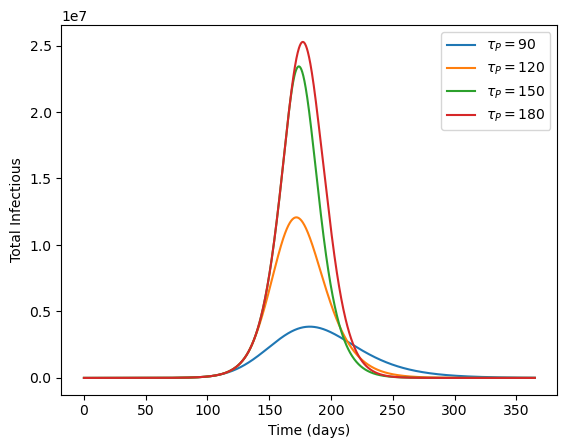

<Figure size 640x480 with 0 Axes>

In [5]:

for tauP in [90.0, 120.0, 150.0, 180.0]:
    times, Y = curves[tauP]
    Itot = Y[:, 4] + Y[:, 8]
    plt.plot(
        times,
        Itot,
        label=rf"$\tau_P = {tauP:.0f}$"
    )

plt.xlabel("Time (days)")
plt.ylabel("Total Infectious")
plt.legend()
plt.savefig("fig1c.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()


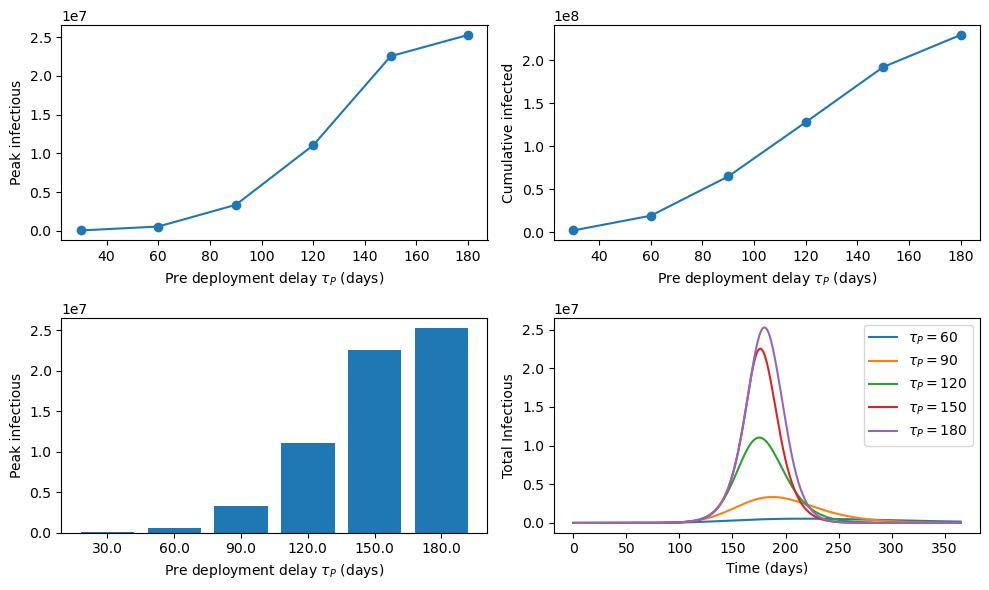

In [15]:
#import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(10, 6))

# Plot 1: Peak infectious vs tauP
axs[0, 0].plot(df["tauP_days"], df["peak_I_total"], marker="o")
axs[0, 0].set_xlabel("Pre deployment delay $\\tau_P$ (days)")
axs[0, 0].set_ylabel("Peak infectious")

# Plot 2: Cumulative infected by day 365 vs tauP
axs[0, 1].plot(df["tauP_days"], df["final_R_total"], marker="o")
axs[0, 1].set_xlabel("Pre deployment delay $\\tau_P$ (days)")
axs[0, 1].set_ylabel("Cumulative infected")
# Plot 3: Peak infectious as bars, categorical
axs[1, 0].bar(
    df["tauP_days"].astype(str),
    df["peak_I_total"]
)
axs[1, 0].set_xlabel("Pre deployment delay $\\tau_P$ (days)")
axs[1, 0].set_ylabel("Peak infectious")

# Plot 4: Time series with math formatted legend
for tauP in [60.0, 90.0, 120.0, 150.0, 180.0]:
    times, Y = curves[tauP]
    Itot = Y[:, 4] + Y[:, 8]
    axs[1, 1].plot(
        times,
        Itot,
        label=rf"$\tau_P = {tauP:.0f}$"
    )

axs[1, 1].set_xlabel("Time (days)")
axs[1, 1].set_ylabel("Total Infectious")
axs[1, 1].legend()

plt.tight_layout()
plt.show()


In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from caas_jupyter_tools import display_dataframe_to_user
except Exception:
    display_dataframe_to_user = None

def simulate_two_group(
    tauV: float,
    T: float = 365.0,
    dt: float = 0.25,
    N0: float = 340110988.0,
    q_accept: float = 0.70,
    I0_total: float = 13.0,
    R0_target: float = 1.7,
    cn: float = 0.40,
    gamma: float = 1.0 / 5.0,
    nu: float = 0.02,
    epsp: float = 0.40,
    tauE: float = 2.0,
    tauP: float = 120.0,
):
    beta = (R0_target * gamma) / (1.0 - cn)
    times = np.arange(0.0, T + dt, dt)
    n = len(times)

    Na0 = q_accept * N0
    Nh0 = (1.0 - q_accept) * N0

    I0a = I0_total * q_accept
    I0h = I0_total * (1.0 - q_accept)

    Sa0 = Na0 - I0a
    Sh0 = Nh0 - I0h

    # Sa, Wa, Pa, Ea, Ia, Ra, Sh, Eh, Ih, Rh
    Y = np.zeros((n, 10), dtype=float)
    Y[0, :] = np.array([Sa0, 0.0, 0.0, 0.0, I0a, 0.0, Sh0, 0.0, I0h, 0.0])

    def delay_index(t_now, delay):
        idx = int((t_now - delay) / dt)
        return 0 if idx < 0 else idx

    def lambda_from_state(state):
        Sa, Wa, Pa, Ea, Ia, Ra, Sh, Eh, Ih, Rh = state
        Itot = Ia + Ih
        Ntot = Sa + Wa + Pa + Ea + Ia + Ra + Sh + Eh + Ih + Rh
        return beta * (1.0 - cn) * (Itot / Ntot)

    for k in range(1, n):
        t_now = times[k]
        prev = Y[k - 1, :]
        Sa, Wa, Pa, Ea, Ia, Ra, Sh, Eh, Ih, Rh = prev

        idxE = delay_index(t_now, tauE)
        idxV = delay_index(t_now, tauV)

        lam = lambda_from_state(prev)
        lam_E = lambda_from_state(Y[idxE, :])

        H_P = 1.0 if t_now >= tauP else 0.0
        H_PV = 1.0 if t_now >= (tauP + tauV) else 0.0

        Sa_V = Y[idxV, 0]
        v_a = nu * H_P * Sa
        g_a = nu * H_PV * Sa_V

        inc_a_now = lam * (Sa + Wa + epsp * Pa)
        inc_h_now = lam * Sh

        Sa_E, Wa_E, Pa_E, Ea_E, Ia_E, Ra_E, Sh_E, Eh_E, Ih_E, Rh_E = Y[idxE, :]
        inc_a_del = lam_E * (Sa_E + Wa_E + epsp * Pa_E)
        inc_h_del = lam_E * Sh_E

        dSa = -lam * Sa - v_a
        dWa = v_a - lam * Wa - g_a
        dPa = g_a - lam * epsp * Pa

        dEa = inc_a_now - inc_a_del
        dIa = inc_a_del - gamma * Ia
        dRa = gamma * Ia

        dSh = -lam * Sh
        dEh = inc_h_now - inc_h_del
        dIh = inc_h_del - gamma * Ih
        dRh = gamma * Ih

        Y[k, 0] = Sa + dt * dSa
        Y[k, 1] = Wa + dt * dWa
        Y[k, 2] = Pa + dt * dPa
        Y[k, 3] = Ea + dt * dEa
        Y[k, 4] = Ia + dt * dIa
        Y[k, 5] = Ra + dt * dRa
        Y[k, 6] = Sh + dt * dSh
        Y[k, 7] = Eh + dt * dEh
        Y[k, 8] = Ih + dt * dIh
        Y[k, 9] = Rh + dt * dRh

        Y[k, :] = np.maximum(Y[k, :], 0.0)

    Ia = Y[:, 4]
    Ih = Y[:, 8]
    Itot = Ia + Ih

    peak_I = float(np.max(Itot))
    t_peak = float(times[int(np.argmax(Itot))])

    final_Ra = float(Y[-1, 5])
    final_Rh = float(Y[-1, 9])
    final_R = final_Ra + final_Rh

    AR_a = final_Ra / Na0
    AR_h = final_Rh / Nh0

    return times, Y, {
        "peak_I_total": peak_I,
        "t_peak_days": t_peak,
        "final_R_total": final_R,
        "final_Ra": final_Ra,
        "final_Rh": final_Rh,
        "AR_accept": AR_a,
        "AR_hesitant": AR_h,
    }

tauV_values = [7.0, 14.0, 21.0, 28.0, 35.0]
rows = []
curves = {}

for tauV in tauV_values:
    times, Y, stats = simulate_two_group(tauV=tauV)
    rows.append({"tauV_days": tauV, **stats})
    curves[tauV] = (times, Y)

df2 = pd.DataFrame(rows).sort_values("tauV_days")

if display_dataframe_to_user:
    display_dataframe_to_user("TauP sweep summary (two group model)", df2)
else:
    df2



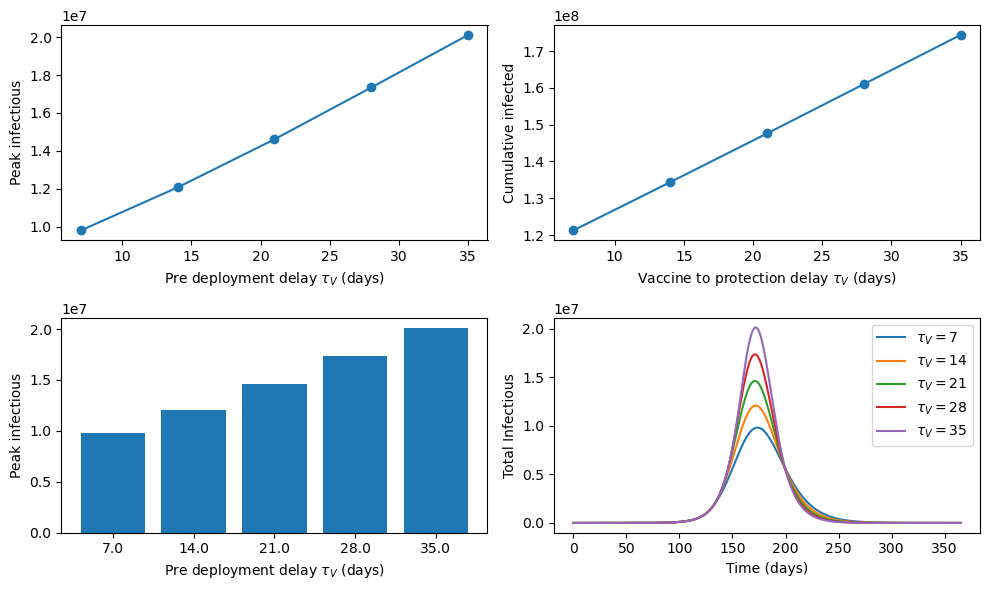

In [60]:
#import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(10, 6))

# Plot 1: Peak infectious vs tauP
axs[0, 0].plot(df2["tauV_days"], df2["peak_I_total"], marker="o")
axs[0, 0].set_xlabel("Pre deployment delay $\\tau_V$ (days)")
axs[0, 0].set_ylabel("Peak infectious")

# Plot 2: Cumulative infected by day 365 vs tauP
# Plot 2: Cumulative infected by day 365 vs tauV
axs[0, 1].plot(df2["tauV_days"], df2["final_R_total"], marker="o")
axs[0, 1].set_xlabel(r"Vaccine to protection delay $\tau_V$ (days)")
axs[0, 1].set_ylabel("Cumulative infected")
# Plot 3: Peak infectious as bars, categorical
axs[1, 0].bar(
    df2["tauV_days"].astype(str),
    df2["peak_I_total"]
)
axs[1, 0].set_xlabel("Pre deployment delay $\\tau_V$ (days)")
axs[1, 0].set_ylabel("Peak infectious")

# Plot 4: Time series with math formatted legend
for tauV in [7,14,21,28,35]:
    times, Y = curves[tauV]
    Itot = Y[:, 4] + Y[:, 8]
    axs[1, 1].plot(
        times,
        Itot,
        label=rf"$\tau_V = {tauV:.0f}$"
    )

axs[1, 1].set_xlabel("Time (days)")
axs[1, 1].set_ylabel("Total Infectious")
axs[1, 1].legend()

plt.tight_layout()
plt.show()


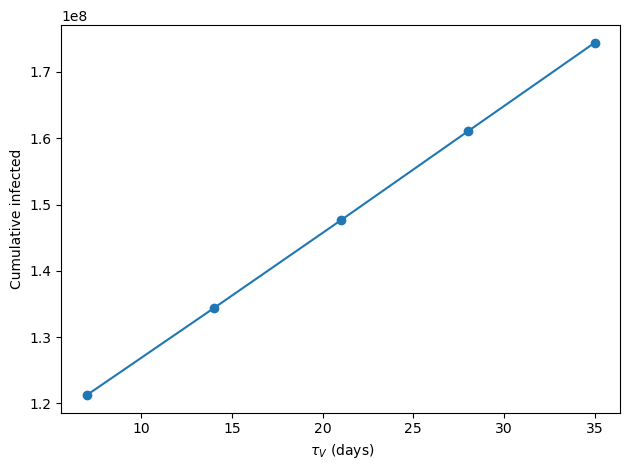

In [33]:
plt.plot(df2["tauV_days"], df2["final_R_total"], marker="o")
plt.xlabel(" $\\tau_V$ (days)")
plt.ylabel("Cumulative infected")
plt.savefig("fig3b.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()


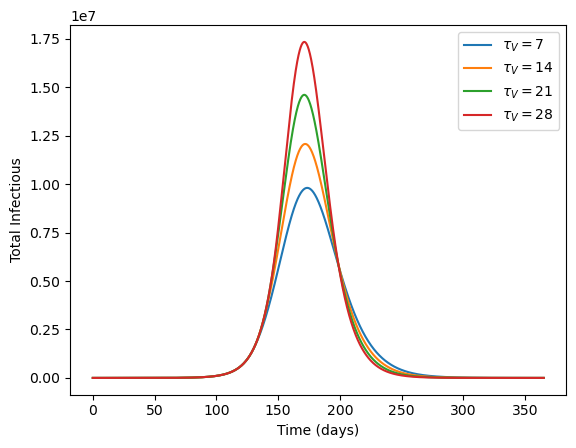

In [61]:

for tauV in [7,14,21,28]:
    times, Y = curves[tauV]
    Itot = Y[:, 4] + Y[:, 8]
    plt.plot(
        times,
        Itot,
        label=rf"$\tau_V = {tauV:.0f}$"
    )

plt.xlabel("Time (days)")
plt.ylabel("Total Infectious")
plt.legend()
#plt.savefig("fig2c.png", dpi=300, bbox_inches="tight")
#plt.tight_layout()
plt.show()


## How does vaccine to protection delay alter control effectiveness

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def simulate_two_group_return_Re(
    tauP: float,
    tauV: float,
    T: float = 365.0,
    dt: float = 0.25,
    N0: float = 340110988.0,
    q_accept: float = 0.70,
    I0_total: float = 13.0,
    R0_target: float = 1.7,
    cn: float = 0.40,
    gamma: float = 1.0 / 5.0,
    nu: float = 0.02,
    epsp: float = 0.40,
    tauE: float = 2.0,
):
    beta = (R0_target * gamma) / (1.0 - cn)
    times = np.arange(0.0, T + dt, dt)
    n = len(times)

    Na0 = q_accept * N0
    Nh0 = (1.0 - q_accept) * N0

    I0a = I0_total * q_accept
    I0h = I0_total * (1.0 - q_accept)

    Sa0 = Na0 - I0a
    Sh0 = Nh0 - I0h

    # Sa, Wa, Pa, Ea, Ia, Ra, Sh, Eh, Ih, Rh
    Y = np.zeros((n, 10), dtype=float)
    Y[0, :] = np.array([Sa0, 0.0, 0.0, 0.0, I0a, 0.0, Sh0, 0.0, I0h, 0.0])

    def delay_index(t_now, delay):
        idx = int((t_now - delay) / dt)
        return 0 if idx < 0 else idx

    def lambda_from_state(state):
        Sa, Wa, Pa, Ea, Ia, Ra, Sh, Eh, Ih, Rh = state
        Itot = Ia + Ih
        Ntot = Sa + Wa + Pa + Ea + Ia + Ra + Sh + Eh + Ih + Rh
        return beta * (1.0 - cn) * (Itot / Ntot)

    for k in range(1, n):
        t_now = times[k]
        prev = Y[k - 1, :]
        Sa, Wa, Pa, Ea, Ia, Ra, Sh, Eh, Ih, Rh = prev

        idxE = delay_index(t_now, tauE)
        idxV = delay_index(t_now, tauV)

        lam = lambda_from_state(prev)
        lam_E = lambda_from_state(Y[idxE, :])

        H_P = 1.0 if t_now >= tauP else 0.0
        H_PV = 1.0 if t_now >= (tauP + tauV) else 0.0

        Sa_V = Y[idxV, 0]
        v_a = nu * H_P * Sa
        g_a = nu * H_PV * Sa_V

        inc_a_now = lam * (Sa + Wa + epsp * Pa)
        inc_h_now = lam * Sh

        Sa_E, Wa_E, Pa_E, Ea_E, Ia_E, Ra_E, Sh_E, Eh_E, Ih_E, Rh_E = Y[idxE, :]
        inc_a_del = lam_E * (Sa_E + Wa_E + epsp * Pa_E)
        inc_h_del = lam_E * Sh_E

        dSa = -lam * Sa - v_a
        dWa = v_a - lam * Wa - g_a
        dPa = g_a - lam * epsp * Pa

        dEa = inc_a_now - inc_a_del
        dIa = inc_a_del - gamma * Ia
        dRa = gamma * Ia

        dSh = -lam * Sh
        dEh = inc_h_now - inc_h_del
        dIh = inc_h_del - gamma * Ih
        dRh = gamma * Ih

        Y[k, 0] = Sa + dt * dSa
        Y[k, 1] = Wa + dt * dWa
        Y[k, 2] = Pa + dt * dPa
        Y[k, 3] = Ea + dt * dEa
        Y[k, 4] = Ia + dt * dIa
        Y[k, 5] = Ra + dt * dRa
        Y[k, 6] = Sh + dt * dSh
        Y[k, 7] = Eh + dt * dEh
        Y[k, 8] = Ih + dt * dIh
        Y[k, 9] = Rh + dt * dRh

        Y[k, :] = np.maximum(Y[k, :], 0.0)

    # Effective reproduction number trajectory
    R0 = R0_target  # by construction
    Sa = Y[:, 0]; Wa = Y[:, 1]; Pa = Y[:, 2]; Sh = Y[:, 6]
    Ntot = np.sum(Y, axis=1)
    Re_t = R0 * (Sa + Wa + epsp * Pa + Sh) / Ntot

    # first crossing time when Re<1 (if any)
    below = np.where(Re_t < 1.0)[0]
    t_cross = float(times[below[0]]) if len(below) > 0 else np.nan

    Ia = Y[:, 4]; Ih = Y[:, 8]; Itot = Ia + Ih
    peak_I = float(np.max(Itot))
    t_peak = float(times[int(np.argmax(Itot))])
    final_R_total = float(Y[-1, 5] + Y[-1, 9])

    return {"peak_I": peak_I, "t_peak": t_peak, "final_R": final_R_total, "t_Re_below1": t_cross}

tauP_grid = [30.0, 60.0, 90.0, 120.0, 150.0, 180.0]
tauV_grid = [7.0, 14.0, 21.0, 28.0]

records = []
peak_mat = np.zeros((len(tauP_grid), len(tauV_grid)))
final_mat = np.zeros_like(peak_mat)
tcross_mat = np.zeros_like(peak_mat)

for i, tauP in enumerate(tauP_grid):
    for j, tauV in enumerate(tauV_grid):
        out = simulate_two_group_return_Re(tauP=tauP, tauV=tauV)
        records.append({"tauP": tauP, "tauV": tauV, **out})
        peak_mat[i, j] = out["peak_I"]
        final_mat[i, j] = out["final_R"]
        tcross_mat[i, j] = out["t_Re_below1"] if np.isfinite(out["t_Re_below1"]) else np.nan

df2 = pd.DataFrame(records).sort_values(["tauP", "tauV"])
#df2


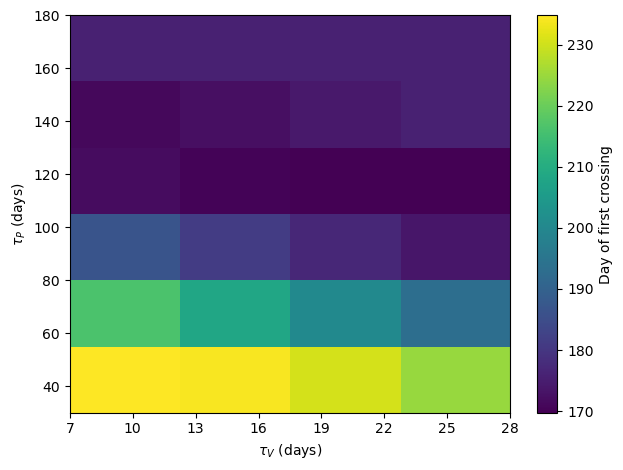

In [69]:
im0 = plt.imshow(
    tcross_mat,
    aspect="auto",
    origin="lower",
    extent=[min(tauV_grid), max(tauV_grid), min(tauP_grid), max(tauP_grid)]
)

plt.xlabel(r"$\tau_V$ (days)")
plt.ylabel(r"$\tau_P$ (days)")

# set custom x-axis ticks
xticks = list(range(7, 31, 3))
plt.xticks(xticks)

plt.colorbar(im0, label="Day of first crossing")
plt.savefig("fig5a.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()



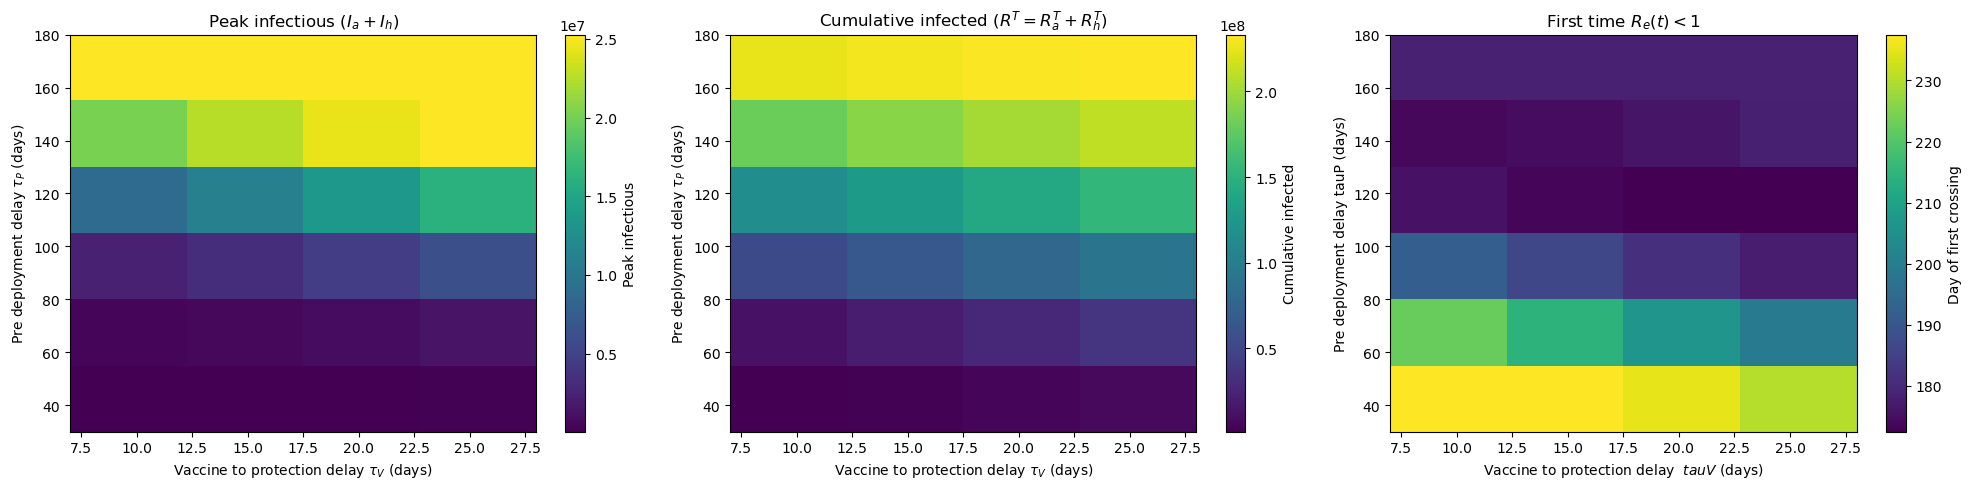

In [29]:
fig, axs = plt.subplots(1, 3, figsize=(20, 5))

# Panel 1
im0 = axs[0].imshow(
    peak_mat, aspect="auto", origin="lower",
    extent=[min(tauV_grid), max(tauV_grid), min(tauP_grid), max(tauP_grid)]
)
axs[0].set_xlabel("Vaccine to protection delay $\\tau_V$ (days)")
axs[0].set_ylabel("Pre deployment delay $\\tau_P$ (days)")
axs[0].set_title("Peak infectious ($I_a + I_h$)")
fig.colorbar(im0, ax=axs[0], label="Peak infectious")

# Panel 2
im1 = axs[1].imshow(
    final_mat, aspect="auto", origin="lower",
    extent=[min(tauV_grid), max(tauV_grid), min(tauP_grid), max(tauP_grid)]
)
axs[1].set_xlabel("Vaccine to protection delay $\\tau_V$ (days)")
axs[1].set_ylabel("Pre deployment delay $\\tau_P$ (days)")
axs[1].set_title("Cumulative infected ($R^T = R_a^T+R_h^T$)")
fig.colorbar(im1, ax=axs[1], label="Cumulative infected")

# Panel 3
im2 = axs[2].imshow(
    tcross_mat, aspect="auto", origin="lower",
    extent=[min(tauV_grid), max(tauV_grid), min(tauP_grid), max(tauP_grid)]
)
axs[2].set_xlabel("Vaccine to protection delay $\\ tau_V$ (days)")
axs[2].set_ylabel("Pre deployment delay $\\ tau_P$ (days)")
axs[2].set_title("First time $ R_e(t) < 1$")
fig.colorbar(im2, ax=axs[2], label="Day of first crossing")

plt.tight_layout()
plt.show()


### Is outbreak size more sensitive to incubation delay, rollout delay, or immune response delay.




In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reuse simulate_two_group but allow tauE, tauP, tauV as inputs
def simulate_two_group_stats(
    tauP: float = 120.0,
    tauV: float = 14.0,
    tauE: float = 2.0,
    T: float = 365.0,
    dt: float = 0.25,
    N0: float = 340110988.0,
    q_accept: float = 0.70,
    I0_total: float = 13.0,
    R0_target: float = 1.7,
    cn: float = 0.40,
    gamma: float = 1.0 / 5.0,
    nu: float = 0.02,
    epsp: float = 0.40,
):
    beta = (R0_target * gamma) / (1.0 - cn)

    times = np.arange(0.0, T + dt, dt)
    n = len(times)

    Na0 = q_accept * N0
    Nh0 = (1.0 - q_accept) * N0

    I0a = I0_total * q_accept
    I0h = I0_total * (1.0 - q_accept)

    Sa0 = Na0 - I0a
    Sh0 = Nh0 - I0h

    # Sa, Wa, Pa, Ea, Ia, Ra, Sh, Eh, Ih, Rh
    Y = np.zeros((n, 10), dtype=float)
    Y[0, :] = np.array([Sa0, 0.0, 0.0, 0.0, I0a, 0.0, Sh0, 0.0, I0h, 0.0])

    def delay_index(t_now, delay):
        idx = int((t_now - delay) / dt)
        return 0 if idx < 0 else idx

    def lambda_from_state(state):
        Sa, Wa, Pa, Ea, Ia, Ra, Sh, Eh, Ih, Rh = state
        Itot = Ia + Ih
        Ntot = Sa + Wa + Pa + Ea + Ia + Ra + Sh + Eh + Ih + Rh
        return beta * (1.0 - cn) * (Itot / Ntot)

    for k in range(1, n):
        t_now = times[k]
        prev = Y[k - 1, :]
        Sa, Wa, Pa, Ea, Ia, Ra, Sh, Eh, Ih, Rh = prev

        idxE = delay_index(t_now, tauE)
        idxV = delay_index(t_now, tauV)

        lam = lambda_from_state(prev)
        lam_E = lambda_from_state(Y[idxE, :])

        H_P = 1.0 if t_now >= tauP else 0.0
        H_PV = 1.0 if t_now >= (tauP + tauV) else 0.0

        Sa_V = Y[idxV, 0]
        v_a = nu * H_P * Sa
        g_a = nu * H_PV * Sa_V

        inc_a_now = lam * (Sa + Wa + epsp * Pa)
        inc_h_now = lam * Sh

        Sa_E, Wa_E, Pa_E, Ea_E, Ia_E, Ra_E, Sh_E, Eh_E, Ih_E, Rh_E = Y[idxE, :]
        inc_a_del = lam_E * (Sa_E + Wa_E + epsp * Pa_E)
        inc_h_del = lam_E * Sh_E

        dSa = -lam * Sa - v_a
        dWa = v_a - lam * Wa - g_a
        dPa = g_a - lam * epsp * Pa

        dEa = inc_a_now - inc_a_del
        dIa = inc_a_del - gamma * Ia
        dRa = gamma * Ia

        dSh = -lam * Sh
        dEh = inc_h_now - inc_h_del
        dIh = inc_h_del - gamma * Ih
        dRh = gamma * Ih

        Y[k, 0] = Sa + dt * dSa
        Y[k, 1] = Wa + dt * dWa
        Y[k, 2] = Pa + dt * dPa
        Y[k, 3] = Ea + dt * dEa
        Y[k, 4] = Ia + dt * dIa
        Y[k, 5] = Ra + dt * dRa
        Y[k, 6] = Sh + dt * dSh
        Y[k, 7] = Eh + dt * dEh
        Y[k, 8] = Ih + dt * dIh
        Y[k, 9] = Rh + dt * dRh

        Y[k, :] = np.maximum(Y[k, :], 0.0)

    Ia = Y[:, 4]
    Ih = Y[:, 8]
    Itot = Ia + Ih

    peak_I = float(np.max(Itot))
    t_peak = float(times[int(np.argmax(Itot))])

    final_R_total = float(Y[-1, 5] + Y[-1, 9])

    # Re(t)
    Sa = Y[:, 0]; Wa = Y[:, 1]; Pa = Y[:, 2]; Sh = Y[:, 6]
    Ntot = np.sum(Y, axis=1)
    Re_t = R0_target * (Sa + Wa + epsp * Pa + Sh) / Ntot
    below = np.where(Re_t < 1.0)[0]
    t_cross = float(times[below[0]]) if len(below) > 0 else np.nan

    return times, Y, {
        "peak_I_total": peak_I,
        "t_peak_days": t_peak,
        "final_R_total": final_R_total,
        "t_Re_below1": t_cross,
    }

# Question 3 sweep over tauE, keeping delayed vaccination baseline tauP=120, tauV=14
tauE_values = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0]
rows = []
curves = {}

for tauE in tauE_values:
    times, Y, stats = simulate_two_group_stats(tauP=120.0, tauV=14.0, tauE=tauE)
    rows.append({"tauE_days": tauE, **stats})
    curves[tauE] = (times, Y)

df3 = pd.DataFrame(rows).sort_values("tauE_days")
df3


,tauE_days,peak_I_total,t_peak_days,final_R_total,t_Re_below1
0,1.0,2.752618e+07,142.50,1.991391e+08,141.75
1,2.0,1.207664e+07,172.00,1.343633e+08,170.50
2,3.0,4.480456e+06,205.50,8.129239e+07,203.25
3,4.0,1.586790e+06,239.75,4.334014e+07,237.00
4,5.0,5.830925e+05,271.50,1.892994e+07,268.00
5,6.0,2.356529e+05,297.25,7.892341e+06,293.25


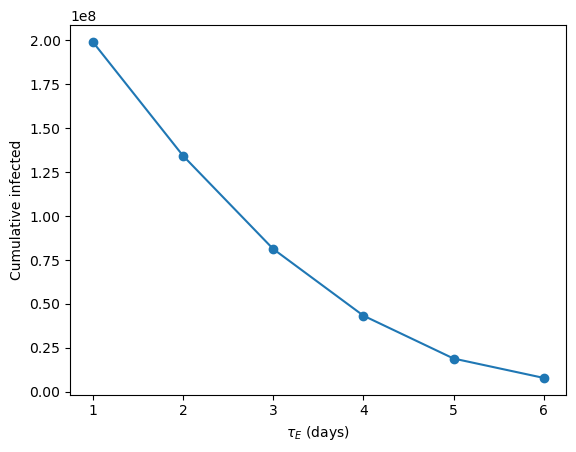

In [65]:
plt.plot(df3["tauE_days"], df3["final_R_total"],  marker="o")
plt.xlabel(r"$\tau_E$ (days)")
plt.ylabel("Cumulative infected")
plt.savefig("fig2b.png", dpi=300, bbox_inches="tight")
plt.show()

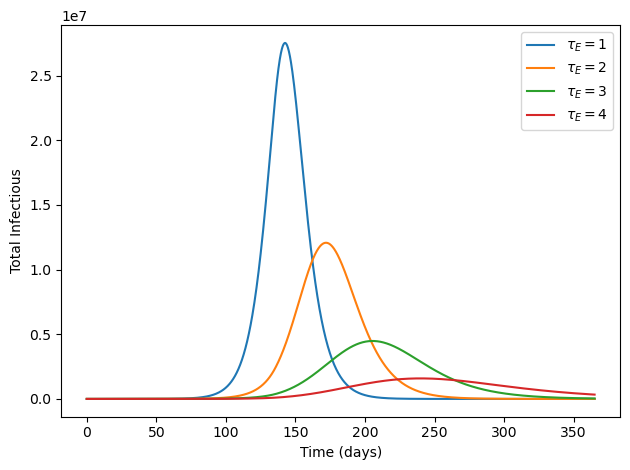

In [64]:

for tauE in [1.0, 2.0, 3.0, 4.0]:
    times, Y = curves[tauE]
    Itot = Y[:, 4] + Y[:, 8]
    plt.plot(
    times,
    Itot,
    label=rf"$\tau_E = {tauE:.0f}$"
    )

plt.xlabel("Time (days)")
plt.ylabel("Total Infectious")
plt.legend()
plt.savefig("fig2c.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()


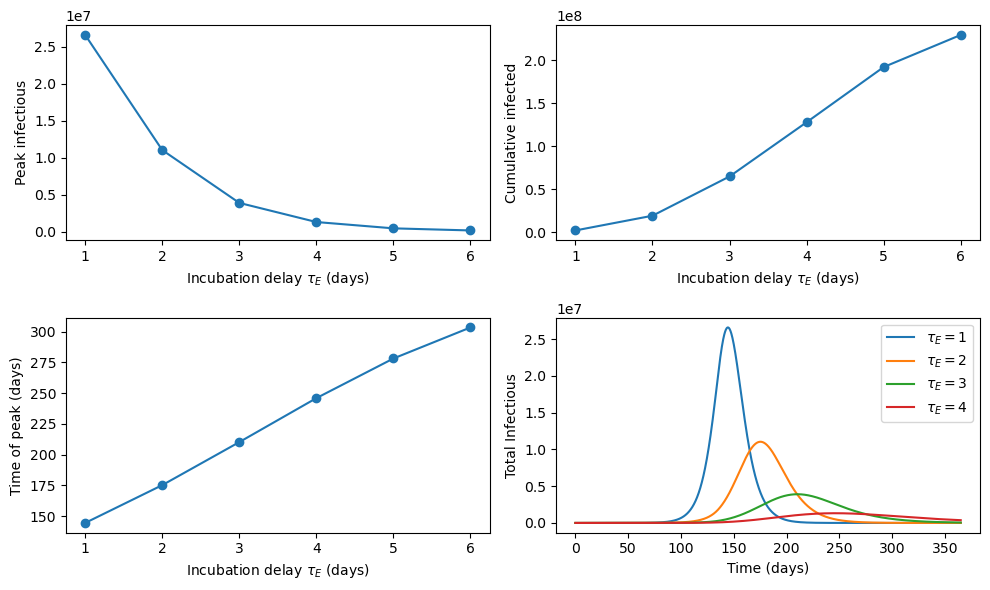

In [38]:
#import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(10, 6))

# Plot 1: Peak infectious vs tauP
axs[0, 0].plot(df3["tauE_days"], df3["peak_I_total"], marker="o")
axs[0, 0].set_xlabel("Incubation delay $\\tau_E$ (days)")
axs[0, 0].set_ylabel("Peak infectious")

# Plot 2: Cumulative infected by day 365 vs tauE
axs[0, 1].plot(df3["tauE_days"], df3["final_R_total"], marker="o")
axs[0, 1].set_xlabel("Incubation delay $\\tau_E$ (days)")
axs[0, 1].set_ylabel("Cumulative infected")

# Plot 3: Peak infectious as bars, categorical
#axs[1, 0].bar(
   # df3["tauE_days"].astype(str),
   # df3["peak_I_total"]
#)
axs[1, 0].plot(df3["tauE_days"], df3["t_peak_days"], marker="o")
axs[1, 0].set_xlabel("Incubation delay tauE (days)")
axs[1, 0].set_ylabel("Time of peak (days)")
axs[1, 0].set_xlabel("Incubation delay $\\tau_E$ (days)")
axs[1, 0].set_ylabel("Time of peak (days)")

# Plot 4: Time series with math formatted legend
for tauE in [1.0, 2.0, 3.0, 4.0]:
    times, Y = curves[tauE]
    Itot = Y[:, 4] + Y[:, 8]
    axs[1, 1].plot(
    times,
    Itot,
    label=rf"$\tau_E = {tauE:.0f}$"
    )

axs[1, 1].set_xlabel("Time (days)")
axs[1, 1].set_ylabel("Total Infectious")
axs[1, 1].legend()

plt.tight_layout()
plt.show()




### How do infection dynamics differ between accepting and hesitant groups

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Core simulator returning full trajectory and derived quantities
def simulate_two_group_full(
    tauP=120.0, tauV=14.0, tauE=2.0,
    T=365.0, dt=0.25,
    N0=340110988.0, q_accept=0.70,
    I0_total=10.0,
    R0_target=1.7, cn=0.40,
    gamma=1.0/5.0, nu=0.02, epsp=0.40,
):
    beta = (R0_target * gamma) / (1.0 - cn)
    times = np.arange(0.0, T + dt, dt)
    n = len(times)

    Na0 = q_accept * N0
    Nh0 = (1.0 - q_accept) * N0

    I0a = I0_total * q_accept
    I0h = I0_total * (1.0 - q_accept)

    Sa0 = Na0 - I0a
    Sh0 = Nh0 - I0h

    # Sa, Wa, Pa, Ea, Ia, Ra, Sh, Eh, Ih, Rh
    Y = np.zeros((n, 10), dtype=float)
    Y[0, :] = np.array([Sa0, 0.0, 0.0, 0.0, I0a, 0.0, Sh0, 0.0, I0h, 0.0])

    def delay_index(t_now, delay):
        idx = int((t_now - delay) / dt)
        return 0 if idx < 0 else idx

    def lam_from_state(state):
        Sa, Wa, Pa, Ea, Ia, Ra, Sh, Eh, Ih, Rh = state
        Itot = Ia + Ih
        Ntot = Sa + Wa + Pa + Ea + Ia + Ra + Sh + Eh + Ih + Rh
        return beta * (1.0 - cn) * (Itot / Ntot)

    for k in range(1, n):
        t = times[k]
        prev = Y[k-1, :]
        Sa, Wa, Pa, Ea, Ia, Ra, Sh, Eh, Ih, Rh = prev

        idxE = delay_index(t, tauE)
        idxV = delay_index(t, tauV)

        lam = lam_from_state(prev)
        lam_E = lam_from_state(Y[idxE, :])

        H_P = 1.0 if t >= tauP else 0.0
        H_PV = 1.0 if t >= (tauP + tauV) else 0.0

        Sa_V = Y[idxV, 0]
        v_a = nu * H_P * Sa
        g_a = nu * H_PV * Sa_V

        inc_a_now = lam * (Sa + Wa + epsp * Pa)
        inc_h_now = lam * Sh

        Sa_E, Wa_E, Pa_E, Ea_E, Ia_E, Ra_E, Sh_E, Eh_E, Ih_E, Rh_E = Y[idxE, :]
        inc_a_del = lam_E * (Sa_E + Wa_E + epsp * Pa_E)
        inc_h_del = lam_E * Sh_E

        dSa = -lam * Sa - v_a
        dWa = v_a - lam * Wa - g_a
        dPa = g_a - lam * epsp * Pa

        dEa = inc_a_now - inc_a_del
        dIa = inc_a_del - gamma * Ia
        dRa = gamma * Ia

        dSh = -lam * Sh
        dEh = inc_h_now - inc_h_del
        dIh = inc_h_del - gamma * Ih
        dRh = gamma * Ih

        Y[k, 0] = Sa + dt * dSa
        Y[k, 1] = Wa + dt * dWa
        Y[k, 2] = Pa + dt * dPa
        Y[k, 3] = Ea + dt * dEa
        Y[k, 4] = Ia + dt * dIa
        Y[k, 5] = Ra + dt * dRa
        Y[k, 6] = Sh + dt * dSh
        Y[k, 7] = Eh + dt * dEh
        Y[k, 8] = Ih + dt * dIh
        Y[k, 9] = Rh + dt * dRh

        Y[k, :] = np.maximum(Y[k, :], 0.0)

    Sa, Wa, Pa, Ea, Ia, Ra, Sh, Eh, Ih, Rh = [Y[:,i] for i in range(10)]
    Itot = Ia + Ih
    Ntot = np.sum(Y, axis=1)

    # Re(t)
    Re_t = R0_target * (Sa + Wa + epsp * Pa + Sh) / Ntot
    below = np.where(Re_t < 1.0)[0]
    t_star = times[below[0]] if len(below) else np.nan

    peak_I = float(np.max(Itot))
    t_peak = float(times[int(np.argmax(Itot))])
    final_Ra = float(Ra[-1])
    final_Rh = float(Rh[-1])
    AR_a = final_Ra / Na0
    AR_h = final_Rh / Nh0
    final_R = final_Ra + final_Rh

    stats = dict(
        peak_I_total=peak_I,
        t_peak_days=t_peak,
        final_R_total=final_R,
        final_Ra=final_Ra,
        final_Rh=final_Rh,
        AR_accept=AR_a,
        AR_hesitant=AR_h,
        t_star=float(t_star) if np.isfinite(t_star) else np.nan,
    )
    return times, Y, Re_t, stats

# Helpers for line + bar plots
def line_and_bar(x, y, xlabel, ylabel, title_prefix=""):
    plt.figure()
    plt.plot(x, y, marker="o")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    if title_prefix:
        plt.title(title_prefix)
    plt.tight_layout()
    plt.show()

    plt.figure()
    plt.bar([str(v) for v in x], y)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    if title_prefix:
        plt.title(title_prefix)
    plt.tight_layout()
    plt.show()

# Baseline parameters used unless specified
BASE = dict(tauP=120.0, tauV=14.0, tauE=2.0, q_accept=0.70, cn=0.40, epsp=0.40)

# ---- Q4 ----
times, Y, Re_t, st = simulate_two_group_full(**BASE)
Ia = Y[:,4]; Ih = Y[:,8]; Ra = Y[:,5]; Rh = Y[:,9]

st


{'peak_I_total': 11035992.671508793,
 't_peak_days': 175.25,
 'final_R_total': 127845722.2695761,
 'final_Ra': 79671442.34152919,
 'final_Rh': 48174279.92804692,
 'AR_accept': 0.3346447195707319,
 'AR_hesitant': 0.47214273798613554,
 't_star': 173.75}

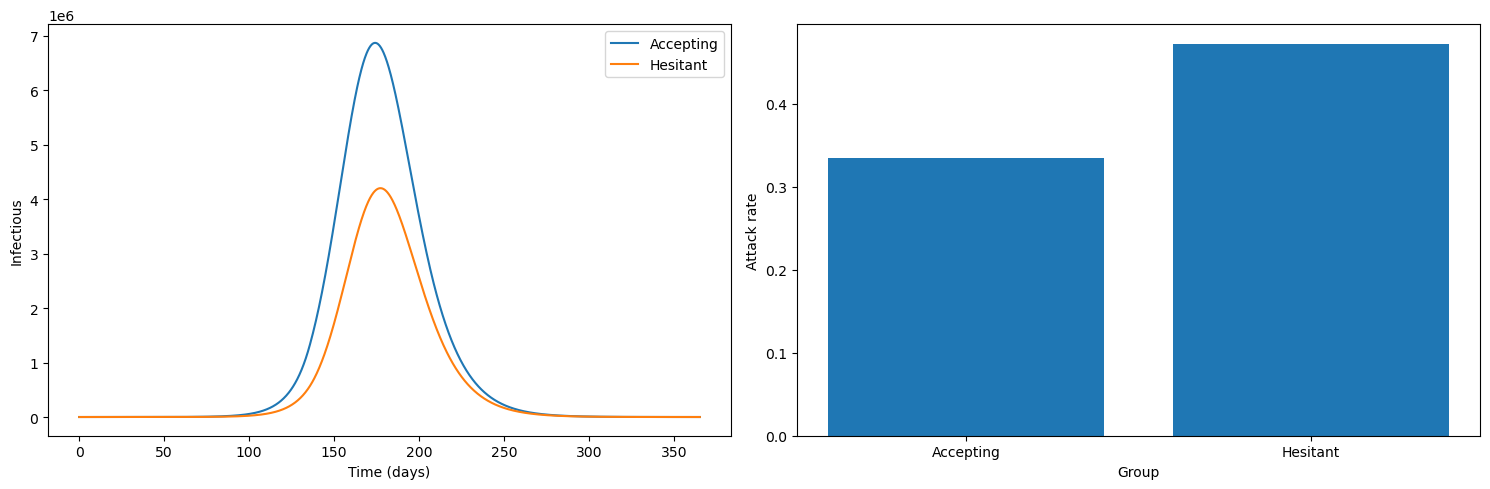

In [36]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

# Panel 1: Time series of infectious by group
axs[0].plot(times, Ia, label="Accepting")
axs[0].plot(times, Ih, label="Hesitant")
axs[0].set_xlabel("Time (days)")
axs[0].set_ylabel("Infectious")
axs[0].legend()

# Panel 2: Attack rates by group
axs[1].bar(
    ["Accepting", "Hesitant"],
    [st["AR_accept"], st["AR_hesitant"]]
)
axs[1].set_xlabel("Group")
axs[1].set_ylabel("Attack rate")

plt.tight_layout()
plt.show()


In [ ]:
im0 = plt.imshow(
    tcross_mat,
    aspect="auto",
    origin="lower",
    extent=[min(tauV_grid), max(tauV_grid), min(tauP_grid), max(tauP_grid)]
)

plt.xlabel(r"$\tau_V$ (days)")
plt.ylabel(r"$\tau_P$ (days)")

# set custom x-axis ticks
xticks = list(range(7, 31, 3))
plt.xticks(xticks)

plt.colorbar(im0, label="Day of first crossing")
plt.savefig("fig5a.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()



C:\Users\Tosin\AppData\Local\Temp\ipykernel_11440\2007044486.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


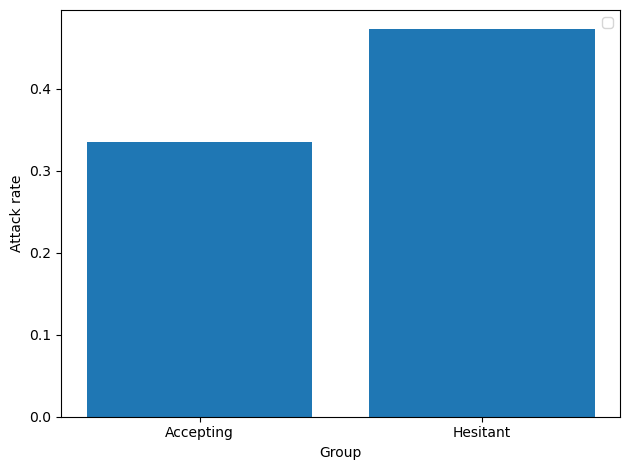

In [39]:
plt.bar(
    ["Accepting", "Hesitant"],
    [st["AR_accept"], st["AR_hesitant"]])
plt.xlabel("Group")
plt.ylabel("Attack rate")
plt.legend()
plt.savefig("fig6b.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

In [ ]:
im0 = plt.imshow(
    tcross_mat,
    aspect="auto",
    origin="lower",
    extent=[min(tauV_grid), max(tauV_grid), min(tauP_grid), max(tauP_grid)]
)

plt.xlabel(r"$\tau_V$ (days)")
plt.ylabel(r"$\tau_P$ (days)")

# set custom x-axis ticks
xticks = list(range(7, 31, 3))
plt.xticks(xticks)

plt.colorbar(im0, label="Day of first crossing")
plt.savefig("fig5a.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()



In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def simulate_two_group_stats(
    tauP,
    tauV,
    tauE,
    T=365.0,
    dt=0.25,
    N0=340110988.0,
    q_accept=0.70,
    I0_total=10.0,
    R0_target=1.7,
    cn=0.40,
    gamma=1.0 / 5.0,
    nu=0.02,
    epsp=0.40,
):
    one_minus_cn = np.subtract(1.0, cn)
    beta = np.divide(np.multiply(R0_target, gamma), one_minus_cn)

    times = np.arange(0.0, np.add(T, dt), dt)
    n = len(times)

    Na0 = np.multiply(q_accept, N0)
    Nh0 = np.multiply(np.subtract(1.0, q_accept), N0)

    I0a = np.multiply(I0_total, q_accept)
    I0h = np.multiply(I0_total, np.subtract(1.0, q_accept))

    Sa0 = np.subtract(Na0, I0a)
    Sh0 = np.subtract(Nh0, I0h)

    Y = np.zeros((n, 10), dtype=float)
    Y[0, :] = np.array([Sa0, 0.0, 0.0, 0.0, I0a, 0.0, Sh0, 0.0, I0h, 0.0])

    def delay_index(t_now, delay):
        idx = int(np.divide(np.subtract(t_now, delay), dt))
        if idx < 0:
            return 0
        return idx

    def lambda_from_state(state):
        Sa, Wa, Pa, Ea, Ia, Ra, Sh, Eh, Ih, Rh = state
        Itot = np.add(Ia, Ih)
        Ntot = np.sum(state)
        return np.multiply(beta, np.multiply(one_minus_cn, np.divide(Itot, Ntot)))

    for k in range(1, n):
        t_now = times[k]
        prev = Y[k - 1, :]

        Sa, Wa, Pa, Ea, Ia, Ra, Sh, Eh, Ih, Rh = prev

        idxE = delay_index(t_now, tauE)
        idxV = delay_index(t_now, tauV)

        lam = lambda_from_state(prev)
        lam_E = lambda_from_state(Y[idxE, :])

        H_P = 1.0 if t_now >= tauP else 0.0
        H_PV = 1.0 if t_now >= np.add(tauP, tauV) else 0.0

        Sa_V = Y[idxV, 0]
        v_a = np.multiply(nu, np.multiply(H_P, Sa))
        g_a = np.multiply(nu, np.multiply(H_PV, Sa_V))

        inc_a_now = np.multiply(lam, np.add(np.add(Sa, Wa), np.multiply(epsp, Pa)))
        inc_h_now = np.multiply(lam, Sh)

        Sa_E, Wa_E, Pa_E, Ea_E, Ia_E, Ra_E, Sh_E, Eh_E, Ih_E, Rh_E = Y[idxE, :]
        inc_a_del = np.multiply(lam_E, np.add(np.add(Sa_E, Wa_E), np.multiply(epsp, Pa_E)))
        inc_h_del = np.multiply(lam_E, Sh_E)

        dSa = np.subtract(np.multiply(-lam, Sa), v_a)
        dWa = np.add(np.add(v_a, np.multiply(-lam, Wa)), np.multiply(-1.0, g_a))
        dPa = np.add(g_a, np.multiply(-lam, np.multiply(epsp, Pa)))

        dEa = np.subtract(inc_a_now, inc_a_del)
        dIa = np.add(inc_a_del, np.multiply(-gamma, Ia))
        dRa = np.multiply(gamma, Ia)

        dSh = np.multiply(-lam, Sh)
        dEh = np.subtract(inc_h_now, inc_h_del)
        dIh = np.add(inc_h_del, np.multiply(-gamma, Ih))
        dRh = np.multiply(gamma, Ih)

        Y[k, 0] = np.add(Sa, np.multiply(dt, dSa))
        Y[k, 1] = np.add(Wa, np.multiply(dt, dWa))
        Y[k, 2] = np.add(Pa, np.multiply(dt, dPa))
        Y[k, 3] = np.add(Ea, np.multiply(dt, dEa))
        Y[k, 4] = np.add(Ia, np.multiply(dt, dIa))
        Y[k, 5] = np.add(Ra, np.multiply(dt, dRa))
        Y[k, 6] = np.add(Sh, np.multiply(dt, dSh))
        Y[k, 7] = np.add(Eh, np.multiply(dt, dEh))
        Y[k, 8] = np.add(Ih, np.multiply(dt, dIh))
        Y[k, 9] = np.add(Rh, np.multiply(dt, dRh))

        Y[k, :] = np.maximum(Y[k, :], 0.0)

    Itot = np.add(Y[:, 4], Y[:, 8])
    peak_I = float(np.max(Itot))
    t_peak = float(times[int(np.argmax(Itot))])
    final_R_total = float(np.add(Y[-1, 5], Y[-1, 9]))

    Sa = Y[:, 0]
    Wa = Y[:, 1]
    Pa = Y[:, 2]
    Ia = Y[k, 4]
    Sh = Y[:, 6]
    Ih = Y[k, 8]
    
    Ntot = np.sum(Y, axis=1)
    Re_t = np.multiply(R0_target, np.divide(np.add(np.add(Sa, Wa), np.add(np.multiply(epsp, Pa), Sh)), Ntot))
    below = np.where(Re_t < 1.0)[0]
    t_cross = float(times[below[0]]) if len(below) > 0 else np.nan

    return {
        "peak_I_total": peak_I,
        "t_peak_days": t_peak,
        "final_R_total": final_R_total,
        "t_Re_below1": t_cross,
    }

# Dominance experiment
base = {"tauP": 120.0, "tauV": 14.0, "tauE": 2.0}
delta = 7.0

base_out = simulate_two_group_stats(tauP=base["tauP"], tauV=base["tauV"], tauE=base["tauE"])

scenarios = [
    ("tauP", np.add(base["tauP"], delta), base["tauV"], base["tauE"]),
    ("tauV", base["tauP"], np.add(base["tauV"], delta), base["tauE"]),
    ("tauE", base["tauP"], base["tauV"], np.add(base["tauE"], delta)),
]

rows = []
for name, tauP_val, tauV_val, tauE_val in scenarios:
    out = simulate_two_group_stats(tauP=tauP_val, tauV=tauV_val, tauE=tauE_val)
    rows.append({
        "parameter": name,
        "tauP": tauP_val,
        "tauV": tauV_val,
        "tauE": tauE_val,
        "peak_I": out["peak_I_total"],
        "final_R": out["final_R_total"],
        "t_peak": out["t_peak_days"],
        "t_Re_below1": out["t_Re_below1"],
    })

df_dom = pd.DataFrame(rows)

# Compute absolute and percent changes relative to baseline
df_dom["delta_peak_I"] = df_dom["peak_I"].apply(lambda x: np.subtract(x, base_out["peak_I_total"]))
df_dom["delta_final_R"] = df_dom["final_R"].apply(lambda x: np.subtract(x, base_out["final_R_total"]))
df_dom["pct_peak_I"] = df_dom["delta_peak_I"].apply(lambda x: np.multiply(100.0, np.divide(x, base_out["peak_I_total"])))
df_dom["pct_final_R"] = df_dom["delta_final_R"].apply(lambda x: np.multiply(100.0, np.divide(x, base_out["final_R_total"])))

df_dom, base_out


(  parameter   tauP  tauV  tauE        peak_I       final_R  t_peak  \
 0      tauP  127.0  14.0   2.0  1.359537e+07  1.434270e+08  174.50   
 1      tauV  120.0  21.0   2.0  1.348237e+07  1.412200e+08  174.25   
 2      tauE  120.0  14.0   9.0  2.326799e+04  7.941754e+05  339.25   
 
    t_Re_below1  delta_peak_I  delta_final_R  pct_peak_I  pct_final_R  
 0       173.00  2.559378e+06   1.558124e+07   23.191190    12.187533  
 1       172.75  2.446377e+06   1.337432e+07   22.167258    10.461297  
 2       333.50 -1.101272e+07  -1.270515e+08  -99.789163   -99.378802  ,
 {'peak_I_total': 11035992.671508804,
  't_peak_days': 175.25,
  'final_R_total': 127845722.26957619,
  't_Re_below1': 173.75})

### What fraction of the population must accept vaccination to suppress transmission

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from textwrap import dedent

def simulate_two_group_full_beta_fixed(
    tauP=120.0, tauV=14.0, tauE=2.0,
    T=365.0, dt=0.25,
    N0=340110988.0, q_accept=0.70,
    I0_total=13.0,
    R0_target=1.7, cn=0.40,
    gamma=1.0/5.0, nu=0.02, epsp=0.40,
    cn_ref=0.40
):
    beta0 = (R0_target * gamma) / (1.0 - cn_ref)
    times = np.arange(0.0, T + dt, dt)
    n = len(times)

    Na0 = q_accept * N0
    Nh0 = (1.0 - q_accept) * N0
    I0a = I0_total * q_accept
    I0h = I0_total * (1.0 - q_accept)
    Sa0 = Na0 - I0a
    Sh0 = Nh0 - I0h

    Y = np.zeros((n, 10), dtype=float)
    Y[0, :] = np.array([Sa0, 0.0, 0.0, 0.0, I0a, 0.0, Sh0, 0.0, I0h, 0.0])

    def delay_index(t_now, delay):
        idx = int((t_now - delay) / dt)
        return 0 if idx < 0 else idx

    def lam_from_state(state):
        Sa, Wa, Pa, Ea, Ia, Ra, Sh, Eh, Ih, Rh = state
        Itot = Ia + Ih
        Ntot = Sa + Wa + Pa + Ea + Ia + Ra + Sh + Eh + Ih + Rh
        return beta0 * (1.0 - cn) * (Itot / Ntot)

    for k in range(1, n):
        t = times[k]
        Sa, Wa, Pa, Ea, Ia, Ra, Sh, Eh, Ih, Rh = Y[k-1, :]

        idxE = delay_index(t, tauE)
        idxV = delay_index(t, tauV)

        lam = lam_from_state(Y[k-1, :])
        lam_E = lam_from_state(Y[idxE, :])

        H_P = 1.0 if t >= tauP else 0.0
        H_PV = 1.0 if t >= (tauP + tauV) else 0.0

        Sa_V = Y[idxV, 0]
        v_a = nu * H_P * Sa
        g_a = nu * H_PV * Sa_V

        inc_a_now = lam * (Sa + Wa + epsp * Pa)
        inc_h_now = lam * Sh

        Sa_E, Wa_E, Pa_E, Ea_E, Ia_E, Ra_E, Sh_E, Eh_E, Ih_E, Rh_E = Y[idxE, :]
        inc_a_del = lam_E * (Sa_E + Wa_E + epsp * Pa_E)
        inc_h_del = lam_E * Sh_E

        dSa = -lam * Sa - v_a
        dWa = v_a - lam * Wa - g_a
        dPa = g_a - lam * epsp * Pa

        dEa = inc_a_now - inc_a_del
        dIa = inc_a_del - gamma * Ia
        dRa = gamma * Ia

        dSh = -lam * Sh
        dEh = inc_h_now - inc_h_del
        dIh = inc_h_del - gamma * Ih
        dRh = gamma * Ih

        Y[k, 0] = Sa + dt * dSa
        Y[k, 1] = Wa + dt * dWa
        Y[k, 2] = Pa + dt * dPa
        Y[k, 3] = Ea + dt * dEa
        Y[k, 4] = Ia + dt * dIa
        Y[k, 5] = Ra + dt * dRa
        Y[k, 6] = Sh + dt * dSh
        Y[k, 7] = Eh + dt * dEh
        Y[k, 8] = Ih + dt * dIh
        Y[k, 9] = Rh + dt * dRh

        Y[k, :] = np.maximum(Y[k, :], 0.0)

    Sa, Wa, Pa, Ea, Ia, Ra, Sh, Eh, Ih, Rh = [Y[:, i] for i in range(10)]
    Itot = Ia + Ih
    Ntot = np.sum(Y, axis=1)

    Re_t = R0_target * ((1.0 - cn) / (1.0 - cn_ref)) * (Sa + Wa + epsp * Pa + Sh) / Ntot

    peak_I_total = float(np.max(Itot))
    t_peak_days = float(times[int(np.argmax(Itot))])
    below = np.where(Re_t < 1.0)[0]
    t_star = float(times[below[0]]) if len(below) else np.nan

    stats = dict(peak_I_total=peak_I_total, t_peak_days=t_peak_days, t_star=t_star)
    return times, Y, Re_t, stats

BASE = dict(tauV=14.0, tauE=2.0, cn=0.40, epsp=0.40, cn_ref=0.40, nu=0.02, R0_target=1.7, gamma=1.0/5.0)
out_dir = "~/Desktop/MetaMath/Compl"
os.makedirs(out_dir, exist_ok=True)

q_vals = np.linspace(0.10, 0.95, 18)
tauP_vals = np.array([30.0, 60.0, 90.0, 120.0, 150.0, 180.0])

peak_mat = np.zeros((len(tauP_vals), len(q_vals)))
tstar_mat = np.full_like(peak_mat, np.nan)
tpeak_mat = np.zeros_like(peak_mat)

for i, tauP in enumerate(tauP_vals):
    for j, q in enumerate(q_vals):
        _, _, _, st = simulate_two_group_full_beta_fixed(tauP=float(tauP), q_accept=float(q), **BASE)
        peak_mat[i, j] = st["peak_I_total"]
        tstar_mat[i, j] = st["t_star"]
        tpeak_mat[i, j] = st["t_peak_days"]

rows = []
for i, tauP in enumerate(tauP_vals):
    q_thr = np.nan
    for j, q in enumerate(q_vals):
        ts = tstar_mat[i, j]
        tp = tpeak_mat[i, j]
        if np.isfinite(ts) and (ts <= tp):
            q_thr = float(q)
            break
    rows.append({"tauP_days": float(tauP), "q_threshold_Re_below_1_before_peak": q_thr})
df_thr = pd.DataFrame(rows)



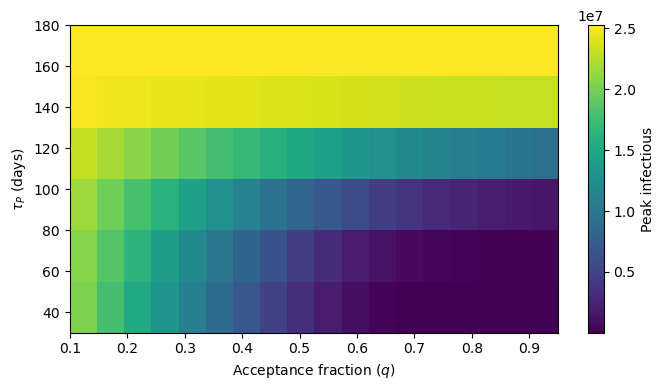

In [67]:
plt.figure(figsize=(7,4))
plt.imshow(
    peak_mat, aspect="auto", origin="lower",
    extent=[float(q_vals[0]), float(q_vals[-1]), float(tauP_vals[0]), float(tauP_vals[-1])]
)
plt.xlabel("Acceptance fraction $(q)$")
plt.ylabel("$\\tau_P$ (days)")
#plt.title("Q5 Peak infectious across q and $\\tau_P$")
plt.colorbar(label="Peak infectious")
plt.tight_layout()
#fig_heat = os.path.join(out_dir, "q5_peak_heatmap.png")
#plt.savefig(fig5b, dpi=200)
#plt.close()
#plt.colorbar(im0, label="Day of first crossing")
plt.savefig("fig5b.png", dpi=300, bbox_inches="tight")
#plt.tight_layout()
plt.show()

### Does early rollout compensate for high hesitancy

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from textwrap import dedent

def simulate_two_group_full_beta_fixed(
    tauP=120.0, tauV=14.0, tauE=2.0,
    T=365.0, dt=0.25,
    N0=340110988.0, q_accept=0.70,
    I0_total=13.0,
    R0_target=1.7, cn=0.40,
    gamma=1.0/5.0, nu=0.02, epsp=0.40,
    cn_ref=0.40
):
    beta0 = np.divide(R0_target * gamma, np.subtract(1.0, cn_ref))
    times = np.arange(0.0, T + dt, dt)
    n = len(times)

    Na0 = q_accept * N0
    Nh0 = np.subtract(1.0, q_accept) * N0

    I0a = I0_total * q_accept
    I0h = I0_total * np.subtract(1.0, q_accept)

    Sa0 = np.subtract(Na0, I0a)
    Sh0 = np.subtract(Nh0, I0h)

    Y = np.zeros((n, 10), dtype=float)
    Y[0, :] = np.array([Sa0, 0.0, 0.0, 0.0, I0a, 0.0, Sh0, 0.0, I0h, 0.0])

    def delay_index(t_now, delay):
        val = np.divide(np.subtract(t_now, delay), dt)
        idx = int(np.floor(val))
        return 0 if idx < 0 else idx

    def lam_from_state(state):
        Sa, Wa, Pa, Ea, Ia, Ra, Sh, Eh, Ih, Rh = state
        Itot = Ia + Ih
        Ntot = Sa + Wa + Pa + Ea + Ia + Ra + Sh + Eh + Ih + Rh
        return beta0 * np.subtract(1.0, cn) * np.divide(Itot, Ntot)

    for k in range(1, n):
        t = times[k]
        Sa, Wa, Pa, Ea, Ia, Ra, Sh, Eh, Ih, Rh = Y[k + np.negative(1), :]

        idxE = delay_index(t, tauE)
        idxV = delay_index(t, tauV)

        lam = lam_from_state(Y[k + np.negative(1), :])
        lam_E = lam_from_state(Y[idxE, :])

        H_P = 1.0 if t >= tauP else 0.0
        H_PV = 1.0 if t >= (tauP + tauV) else 0.0

        Sa_V = Y[idxV, 0]
        v_a = nu * H_P * Sa
        g_a = nu * H_PV * Sa_V

        inc_a_now = lam * (Sa + Wa + epsp * Pa)
        inc_h_now = lam * Sh

        Sa_E, Wa_E, Pa_E, Ea_E, Ia_E, Ra_E, Sh_E, Eh_E, Ih_E, Rh_E = Y[idxE, :]
        inc_a_del = lam_E * (Sa_E + Wa_E + epsp * Pa_E)
        inc_h_del = lam_E * Sh_E

        dSa = np.negative(lam * Sa) + np.negative(v_a)
        dWa = v_a + np.negative(lam * Wa) + np.negative(g_a)
        dPa = g_a + np.negative(lam * epsp * Pa)

        dEa = inc_a_now + np.negative(inc_a_del)
        dIa = inc_a_del + np.negative(gamma * Ia)
        dRa = gamma * Ia

        dSh = np.negative(lam * Sh)
        dEh = inc_h_now + np.negative(inc_h_del)
        dIh = inc_h_del + np.negative(gamma * Ih)
        dRh = gamma * Ih

        Y[k, 0] = Sa + dt * dSa
        Y[k, 1] = Wa + dt * dWa
        Y[k, 2] = Pa + dt * dPa
        Y[k, 3] = Ea + dt * dEa
        Y[k, 4] = Ia + dt * dIa
        Y[k, 5] = Ra + dt * dRa
        Y[k, 6] = Sh + dt * dSh
        Y[k, 7] = Eh + dt * dEh
        Y[k, 8] = Ih + dt * dIh
        Y[k, 9] = Rh + dt * dRh

        Y[k, :] = np.maximum(Y[k, :], 0.0)

    final_R_total = float(Y[n + np.negative(1), 5] + Y[n + np.negative(1), 9])
    Itot = Y[:, 4] + Y[:, 8]
    peak_I_total = float(np.max(Itot))
    t_peak_days = float(times[int(np.argmax(Itot))])

    stats = dict(final_R_total=final_R_total, peak_I_total=peak_I_total, t_peak_days=t_peak_days)
    return times, Y, stats

BASE = dict(tauV=14.0, tauE=2.0, cn=0.40, epsp=0.40, cn_ref=0.40, nu=0.02, R0_target=1.7, gamma=1.0/5.0)

out_dir = "~/Desktop/MetaMath/Compl"
os.makedirs(out_dir, exist_ok=True)

q_vals = np.linspace(0.10, 0.95, 18)
tauP_vals = np.array([30.0, 60.0, 90.0, 120.0, 150.0, 180.0])

final_mat = np.zeros((len(tauP_vals), len(q_vals)))
peak_mat = np.zeros_like(final_mat)
tpeak_mat = np.zeros_like(final_mat)



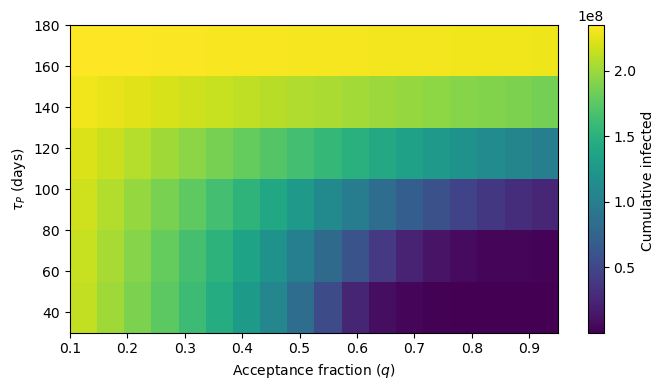

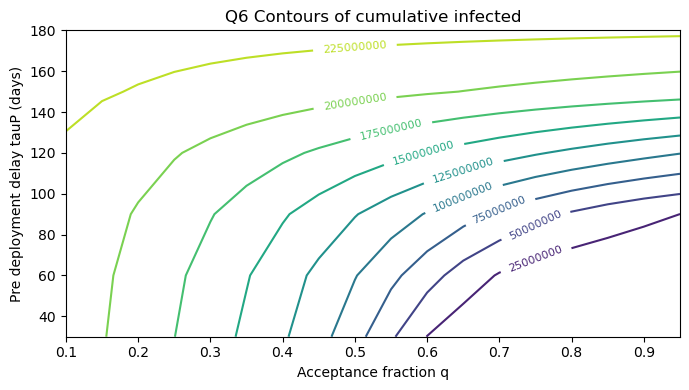

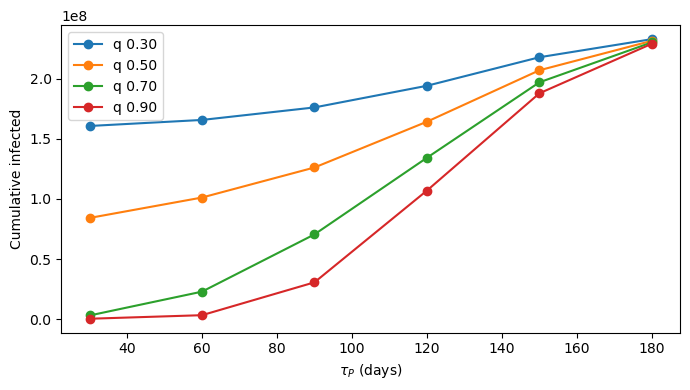

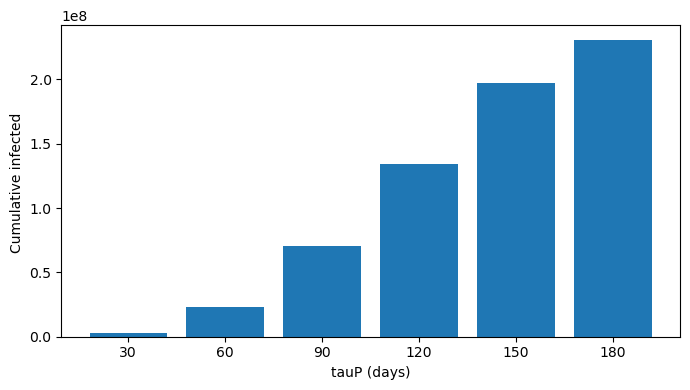

In [44]:
for i, tauP in enumerate(tauP_vals):
    for j, q in enumerate(q_vals):
        _, _, st = simulate_two_group_full_beta_fixed(tauP=float(tauP), q_accept=float(q), **BASE)
        final_mat[i, j] = st["final_R_total"]
        peak_mat[i, j] = st["peak_I_total"]
        tpeak_mat[i, j] = st["t_peak_days"]

# Heat map final size
q_last = q_vals[int(len(q_vals) + np.negative(1))]
tauP_last = tauP_vals[int(len(tauP_vals) + np.negative(1))]

plt.figure(figsize=(7,4))
plt.imshow(
    final_mat, aspect="auto", origin="lower",
    extent=[float(q_vals[0]), float(q_last), float(tauP_vals[0]), float(tauP_last)]
)

plt.xlabel("Acceptance fraction $(q)$")
plt.ylabel("$\\tau_P$ (days)")
#plt.title("Q6 Cumulative infected across q and tauP")
plt.colorbar(label="Cumulative infected ")
plt.tight_layout()
fig_heat = os.path.join(out_dir, "fig5c.png")
plt.savefig(fig_heat, dpi=200)
#plt.close()
plt.show()
# Contour plot for final size
Q, TP = np.meshgrid(q_vals, tauP_vals)
plt.figure(figsize=(7,4))
cs = plt.contour(Q, TP, final_mat, levels=10)
plt.clabel(cs, inline=True, fontsize=8)
plt.xlabel("Acceptance fraction q")
plt.ylabel("Pre deployment delay tauP (days)")
plt.tight_layout()
fig_contour = os.path.join(out_dir, "q6_final_contour.png")
#plt.savefig(fig_contour, dpi=200)
#plt.close()

# Slice plots: final size vs tauP for selected q values
q_sel = [0.30, 0.50, 0.70, 0.90]
slice_rows = []
for q in q_sel:
    vals = []
    for tauP in tauP_vals:
        _, _, st = simulate_two_group_full_beta_fixed(tauP=float(tauP), q_accept=float(q), **BASE)
        vals.append(st["final_R_total"])
    slice_rows.append(vals)
    for tauP, v in zip(tauP_vals, vals):
        slice_rows[-1]  # no op
slice_arr = np.array(slice_rows)

plt.figure(figsize=(7,4))
for idx, q in enumerate(q_sel):
    plt.plot(tauP_vals, slice_arr[idx, :], marker="o", label=f"q {q:.2f}")
plt.xlabel("$\\tau_P$ (days)")
plt.ylabel("Cumulative infected")
#plt.title("Q6 Final size vs tauP for selected q")
plt.legend()
plt.tight_layout()
fig_slice_line = os.path.join(out_dir, "q6_final_vs_tauP_lines.png")
#plt.savefig(fig_slice_line, dpi=200)
#plt.close()

# Bar chart version for q 0.70
q_bar = 0.70
vals_bar = []
for tauP in tauP_vals:
    _, _, st = simulate_two_group_full_beta_fixed(tauP=float(tauP), q_accept=float(q_bar), **BASE)
    vals_bar.append(st["final_R_total"])

plt.figure(figsize=(7,4))
plt.bar([str(int(v)) for v in tauP_vals], vals_bar)
plt.xlabel("tauP (days)")
plt.ylabel("Cumulative infected ")
#plt.title("Q6 Final size vs tauP at q 0.70")
plt.tight_layout()
fig_bar = os.path.join(out_dir, "fig555.png")
#plt.savefig(fig_bar, dpi=200)
#plt.close()

# Save table grids
grid_rows = []
for i, tauP in enumerate(tauP_vals):
    for j, q in enumerate(q_vals):
        grid_rows.append({
            "tauP_days": float(tauP),
            "q": float(q),
            "final_R_total": float(final_mat[i, j]),
            "peak_I_total": float(peak_mat[i, j]),
            "t_peak_days": float(tpeak_mat[i, j])
        })
df_grid = pd.DataFrame(grid_rows)
csv_grid = os.path.join(out_dir, "q6_grid_summary.csv")
df_grid.to_csv(csv_grid, index=False)

# Trade off summary: for each tauP, how much q reduces final size relative to q 0.10
ref_q = float(q_vals[0])
trade_rows = []
for i, tauP in enumerate(tauP_vals):
    ref_val = float(final_mat[i, 0])
    best_val = float(final_mat[i, int(len(q_vals) + np.negative(1))])
    trade_rows.append({
        "tauP_days": float(tauP),
        "final_R_at_q_0_10": ref_val,
        "final_R_at_q_0_95": best_val,
        "cases_averted_by_raising_q": float(np.subtract(ref_val, best_val))
    })
df_trade = pd.DataFrame(trade_rows)
csv_trade = os.path.join(out_dir, "q6_tradeoff_table.csv")
df_trade.to_csv(csv_trade, index=False)




## Can non pharmaceutical compliance delay epidemic peaks

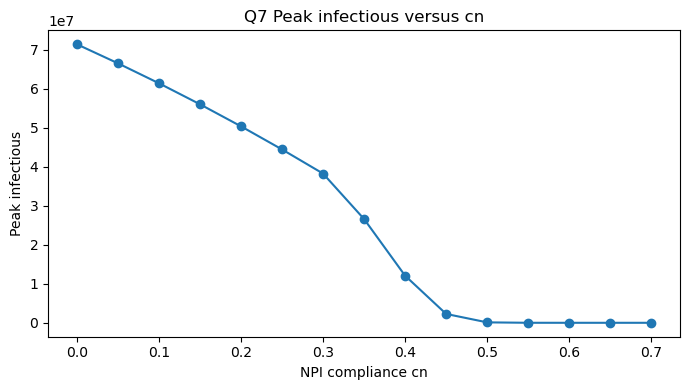

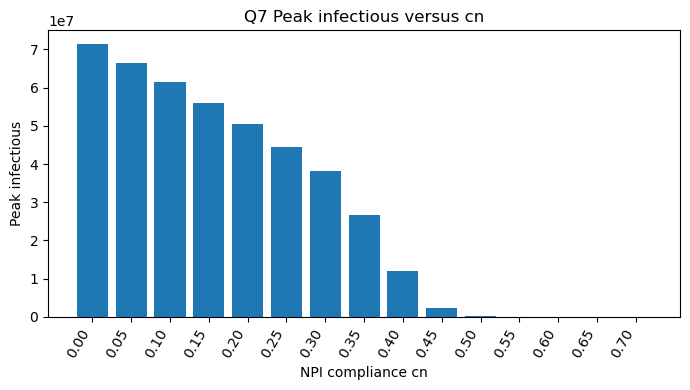

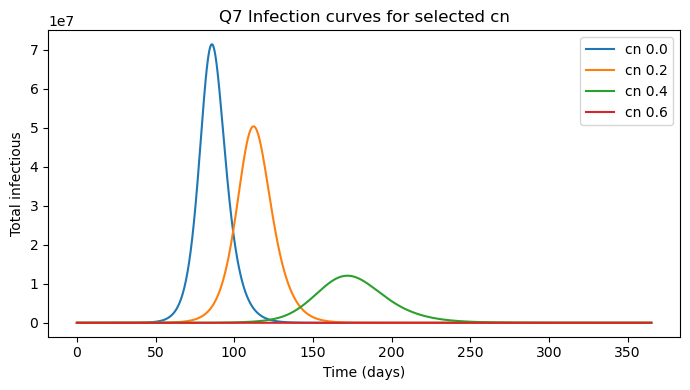

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from textwrap import dedent

# Simulator with fixed beta baseline so cn has consistent meaning
def simulate_two_group_full_beta_fixed(
    tauP=120.0, tauV=14.0, tauE=2.0,
    T=365.0, dt=0.25,
    N0=340110988.0, q_accept=0.70,
    I0_total=13.0,
    R0_target=1.7, cn=0.40,
    gamma=1.0/5.0, nu=0.02, epsp=0.40,
    cn_ref=0.40
):
    beta0 = (R0_target * gamma) / (1.0 - cn_ref)
    times = np.arange(0.0, T + dt, dt)
    n = len(times)

    Na0 = q_accept * N0
    Nh0 = (1.0 - q_accept) * N0
    I0a = I0_total * q_accept
    I0h = I0_total * (1.0 - q_accept)
    Sa0 = Na0 - I0a
    Sh0 = Nh0 - I0h

    Y = np.zeros((n, 10), dtype=float)
    Y[0, :] = np.array([Sa0, 0.0, 0.0, 0.0, I0a, 0.0, Sh0, 0.0, I0h, 0.0])

    def delay_index(t_now, delay):
        idx = int((t_now - delay) / dt)
        return 0 if idx < 0 else idx

    def lam_from_state(state):
        Sa, Wa, Pa, Ea, Ia, Ra, Sh, Eh, Ih, Rh = state
        Itot = Ia + Ih
        Ntot = Sa + Wa + Pa + Ea + Ia + Ra + Sh + Eh + Ih + Rh
        return beta0 * (1.0 - cn) * (Itot / Ntot)

    for k in range(1, n):
        t = times[k]
        Sa, Wa, Pa, Ea, Ia, Ra, Sh, Eh, Ih, Rh = Y[k-1, :]

        idxE = delay_index(t, tauE)
        idxV = delay_index(t, tauV)

        lam = lam_from_state(Y[k-1, :])
        lam_E = lam_from_state(Y[idxE, :])

        H_P = 1.0 if t >= tauP else 0.0
        H_PV = 1.0 if t >= (tauP + tauV) else 0.0

        Sa_V = Y[idxV, 0]
        v_a = nu * H_P * Sa
        g_a = nu * H_PV * Sa_V

        inc_a_now = lam * (Sa + Wa + epsp * Pa)
        inc_h_now = lam * Sh

        Sa_E, Wa_E, Pa_E, Ea_E, Ia_E, Ra_E, Sh_E, Eh_E, Ih_E, Rh_E = Y[idxE, :]
        inc_a_del = lam_E * (Sa_E + Wa_E + epsp * Pa_E)
        inc_h_del = lam_E * Sh_E

        dSa = -lam * Sa - v_a
        dWa = v_a - lam * Wa - g_a
        dPa = g_a - lam * epsp * Pa

        dEa = inc_a_now - inc_a_del
        dIa = inc_a_del - gamma * Ia
        dRa = gamma * Ia

        dSh = -lam * Sh
        dEh = inc_h_now - inc_h_del
        dIh = inc_h_del - gamma * Ih
        dRh = gamma * Ih

        Y[k, 0] = Sa + dt * dSa
        Y[k, 1] = Wa + dt * dWa
        Y[k, 2] = Pa + dt * dPa
        Y[k, 3] = Ea + dt * dEa
        Y[k, 4] = Ia + dt * dIa
        Y[k, 5] = Ra + dt * dRa
        Y[k, 6] = Sh + dt * dSh
        Y[k, 7] = Eh + dt * dEh
        Y[k, 8] = Ih + dt * dIh
        Y[k, 9] = Rh + dt * dRh

        Y[k, :] = np.maximum(Y[k, :], 0.0)

    Ia = Y[:, 4]
    Ih = Y[:, 8]
    Itot = Ia + Ih
    peak_I_total = float(np.max(Itot))
    t_peak_days = float(times[int(np.argmax(Itot))])
    final_R_total = float(Y[-1, 5] + Y[-1, 9])

    stats = dict(peak_I_total=peak_I_total, t_peak_days=t_peak_days, final_R_total=final_R_total)
    return times, Y, stats

BASE = dict(tauP=120.0, tauV=14.0, tauE=2.0, q_accept=0.70, epsp=0.40, cn_ref=0.40, nu=0.02, R0_target=1.7, gamma=1.0/5.0)
out_dir = "~/Desktop/MetaMath/Compl"#"/mnt/data/q7_stepwise"
os.makedirs(out_dir, exist_ok=True)

cn_vals = np.linspace(0.0, 0.70, 15)

peak_list = []
tpeak_list = []
final_list = []


for cn in cn_vals:
    _, _, st = simulate_two_group_full_beta_fixed(cn=float(cn), **BASE)
    peak_list.append(st["peak_I_total"])
    tpeak_list.append(st["t_peak_days"])
    final_list.append(st["final_R_total"])

df = pd.DataFrame({
    "cn": cn_vals,
    "peak_I_total": peak_list,
    "t_peak_days": tpeak_list,
    "final_R_total": final_list
})

csv_path = os.path.join(out_dir, "q7_summary_table.csv")
df.to_csv(csv_path, index=False)



# Peak height line
plt.figure(figsize=(7,4))
plt.plot(df["cn"], df["peak_I_total"], marker="o")
plt.xlabel("NPI compliance cn")
plt.ylabel("Peak infectious")
plt.tight_layout()
fig_p_line = os.path.join(out_dir, "q7_peak_I_line.png")
#plt.savefig(fig_p_line, dpi=200)
#plt.close()

# Peak height bar
plt.figure(figsize=(7,4))
plt.bar([f"{v:.2f}" for v in df["cn"]], df["peak_I_total"])
plt.xlabel("NPI compliance cn")
plt.ylabel("Peak infectious")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
fig_p_bar = os.path.join(out_dir, "q7_peak_I_bar.png")
#plt.savefig(fig_p_bar, dpi=200)
#plt.close()

# Add an overlay of Itot trajectories for selected cn to visually show time gained
cn_sel = [0.0, 0.2, 0.4, 0.6]
plt.figure(figsize=(7,4))
for cn in cn_sel:
    t, Y, _ = simulate_two_group_full_beta_fixed(cn=float(cn), **BASE)
    Itot = Y[:,4] + Y[:,8]
    plt.plot(t, Itot, label=f"cn {cn:.1f}")
plt.xlabel("Time (days)")
plt.ylabel("Total infectious")
plt.legend()
plt.tight_layout()
fig_overlay = os.path.join(out_dir, "q7_Itot_overlay.png")
#plt.savefig(fig_overlay, dpi=200)
#plt.close()



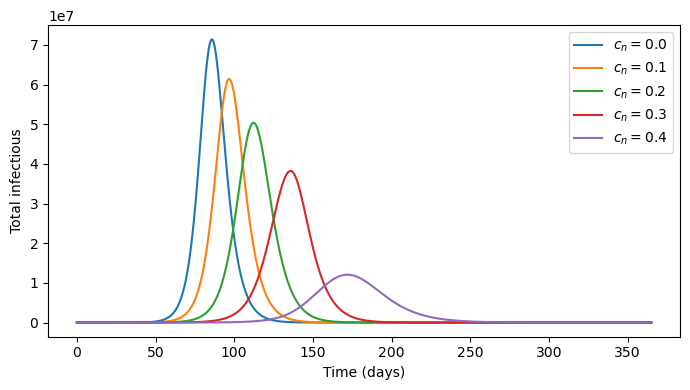

In [53]:
cn_sel = [0.0, 0.1, 0.2, 0.3, 0.4]
plt.figure(figsize=(7,4))
for cn in cn_sel:
    t, Y, _ = simulate_two_group_full_beta_fixed(cn=float(cn), **BASE)
    Itot = Y[:,4] + Y[:,8]
    plt.plot(t, Itot, label=rf"$c_n = {cn:.1f}$")
plt.xlabel("Time (days)")
plt.ylabel("Total infectious")
plt.legend()
plt.savefig("fig7a.png", dpi=300, bbox_inches="tight")
plt.tight_layout() 
plt.show()

### Can strong NPIs compensate for delayed vaccination




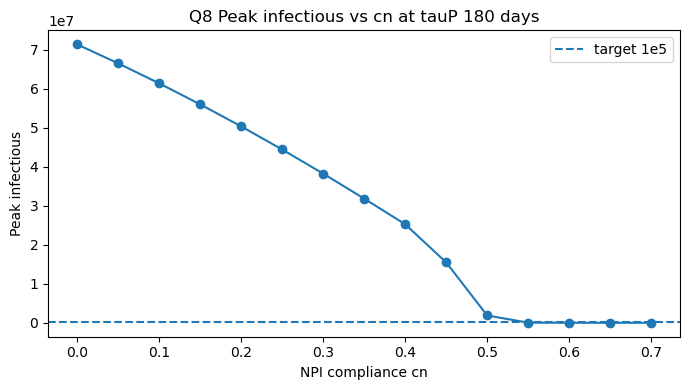

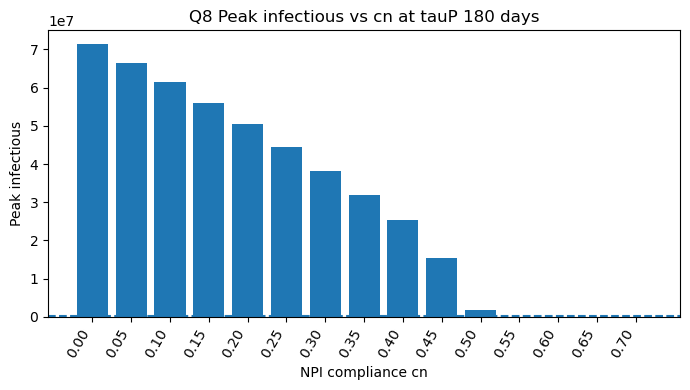

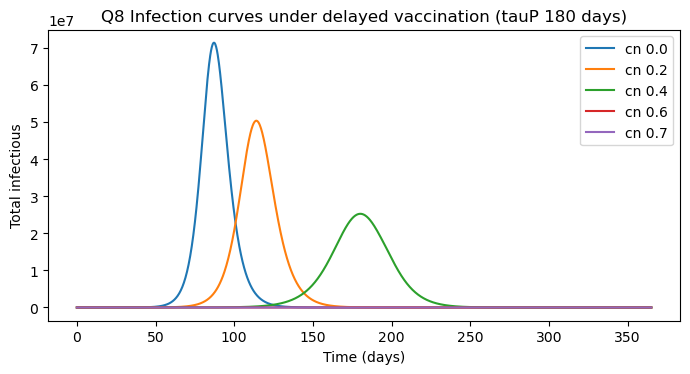

In [76]:
#"~/Desktop/MetaMath/Compl"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from textwrap import dedent

# Simulator (same as Q7)
def simulate_two_group_full_beta_fixed(
    tauP=120.0, tauV=14.0, tauE=2.0,
    T=365.0, dt=0.25,
    N0=340110988.0, q_accept=0.70,
    I0_total=10.0,
    R0_target=1.7, cn=0.40,
    gamma=1.0/5.0, nu=0.02, epsp=0.40,
    cn_ref=0.40
):
    beta0 = (R0_target * gamma) / (1.0 - cn_ref)
    times = np.arange(0.0, T + dt, dt)
    n = len(times)

    Na0 = q_accept * N0
    Nh0 = (1.0 - q_accept) * N0
    I0a = I0_total * q_accept
    I0h = I0_total * (1.0 - q_accept)
    Sa0 = Na0 - I0a
    Sh0 = Nh0 - I0h

    Y = np.zeros((n, 10), dtype=float)
    Y[0, :] = np.array([Sa0, 0.0, 0.0, 0.0, I0a, 0.0, Sh0, 0.0, I0h, 0.0])

    def delay_index(t_now, delay):
        idx = int((t_now - delay) / dt)
        return 0 if idx < 0 else idx

    def lam_from_state(state):
        Sa, Wa, Pa, Ea, Ia, Ra, Sh, Eh, Ih, Rh = state
        Itot = Ia + Ih
        Ntot = Sa + Wa + Pa + Ea + Ia + Ra + Sh + Eh + Ih + Rh
        return beta0 * (1.0 - cn) * (Itot / Ntot)

    for k in range(1, n):
        t = times[k]
        Sa, Wa, Pa, Ea, Ia, Ra, Sh, Eh, Ih, Rh = Y[k-1, :]

        idxE = delay_index(t, tauE)
        idxV = delay_index(t, tauV)

        lam = lam_from_state(Y[k-1, :])
        lam_E = lam_from_state(Y[idxE, :])

        H_P = 1.0 if t >= tauP else 0.0
        H_PV = 1.0 if t >= (tauP + tauV) else 0.0

        Sa_V = Y[idxV, 0]
        v_a = nu * H_P * Sa
        g_a = nu * H_PV * Sa_V

        inc_a_now = lam * (Sa + Wa + epsp * Pa)
        inc_h_now = lam * Sh

        Sa_E, Wa_E, Pa_E, Ea_E, Ia_E, Ra_E, Sh_E, Eh_E, Ih_E, Rh_E = Y[idxE, :]
        inc_a_del = lam_E * (Sa_E + Wa_E + epsp * Pa_E)
        inc_h_del = lam_E * Sh_E

        dSa = -lam * Sa - v_a
        dWa = v_a - lam * Wa - g_a
        dPa = g_a - lam * epsp * Pa

        dEa = inc_a_now - inc_a_del
        dIa = inc_a_del - gamma * Ia
        dRa = gamma * Ia

        dSh = -lam * Sh
        dEh = inc_h_now - inc_h_del
        dIh = inc_h_del - gamma * Ih
        dRh = gamma * Ih

        Y[k, 0] = Sa + dt * dSa
        Y[k, 1] = Wa + dt * dWa
        Y[k, 2] = Pa + dt * dPa
        Y[k, 3] = Ea + dt * dEa
        Y[k, 4] = Ia + dt * dIa
        Y[k, 5] = Ra + dt * dRa
        Y[k, 6] = Sh + dt * dSh
        Y[k, 7] = Eh + dt * dEh
        Y[k, 8] = Ih + dt * dIh
        Y[k, 9] = Rh + dt * dRh

        Y[k, :] = np.maximum(Y[k, :], 0.0)

    Itot = Y[:, 4] + Y[:, 8]
    peak_I_total = float(np.max(Itot))
    t_peak_days = float(times[int(np.argmax(Itot))])
    final_R_total = float(Y[-1, 5] + Y[-1, 9])
    stats = dict(peak_I_total=peak_I_total, t_peak_days=t_peak_days, final_R_total=final_R_total)
    return times, Y, stats

# Q8: fix large tauP and vary cn, check if peak remains "small"
BASE = dict(tauV=14.0, tauE=2.0, q_accept=0.70, epsp=0.40, cn_ref=0.40, nu=0.02, R0_target=1.7, gamma=1.0/5.0)
out_dir = "~/Desktop/MetaMath/Compl"
os.makedirs(out_dir, exist_ok=True)

tauP_fixed = 180.0
cn_vals = np.linspace(0.0, 0.70, 15)

rows = []
for cn in cn_vals:
    t, Y, st = simulate_two_group_full_beta_fixed(tauP=tauP_fixed, cn=float(cn), **BASE)
    rows.append({"cn": float(cn), "peak_I_total": st["peak_I_total"], "t_peak_days": st["t_peak_days"], "final_R_total": st["final_R_total"]})
df = pd.DataFrame(rows)

csv_path = os.path.join(out_dir, "q8_summary_table.csv")
df.to_csv(csv_path, index=False)

# Determine cn threshold for peak below target
peak_target = 1e5
cn_thr = np.nan
for _, r in df.iterrows():
    if r["peak_I_total"] <= peak_target:
        cn_thr = float(r["cn"])
        break

# Line plot peak vs cn with target line
plt.figure(figsize=(7,4))
plt.plot(df["cn"], df["peak_I_total"], marker="o")
plt.axhline(peak_target, linestyle="--", label="target 1e5")
plt.xlabel("NPI compliance cn")
plt.ylabel("Peak infectious")
plt.legend()
plt.tight_layout()
fig_peak_line = os.path.join(out_dir, "q8_peak_vs_cn_line.png")
#plt.savefig(fig_peak_line, dpi=200)
#plt.close()

# Bar chart peak vs cn
plt.figure(figsize=(7,4))
plt.bar([f"{v:.2f}" for v in df["cn"]], df["peak_I_total"])
plt.axhline(peak_target, linestyle="--")
plt.xlabel("NPI compliance cn")
plt.ylabel("Peak infectious")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
fig_peak_bar = os.path.join(out_dir, "q8_peak_vs_cn_bar.png")
#plt.savefig(fig_peak_bar, dpi=200)
#plt.close()

# Overlay infection curves for selected cn
cn_sel = [0.0, 0.2, 0.4, 0.6, 0.7]
plt.figure(figsize=(7,4))
for cn in cn_sel:
    t, Y, _ = simulate_two_group_full_beta_fixed(tauP=tauP_fixed, cn=float(cn), **BASE)
    Itot = Y[:, 4] + Y[:, 8]
    plt.plot(t, Itot, label=f"cn {cn:.1f}")
plt.xlabel("Time (days)")
plt.ylabel("Total infectious")
plt.legend()
plt.tight_layout()
fig_overlay = os.path.join(out_dir, "q8_Itot_overlay.png")
#plt.savefig(fig_overlay, dpi=200)
#plt.close()




### How does leaky protection alter epidemic control

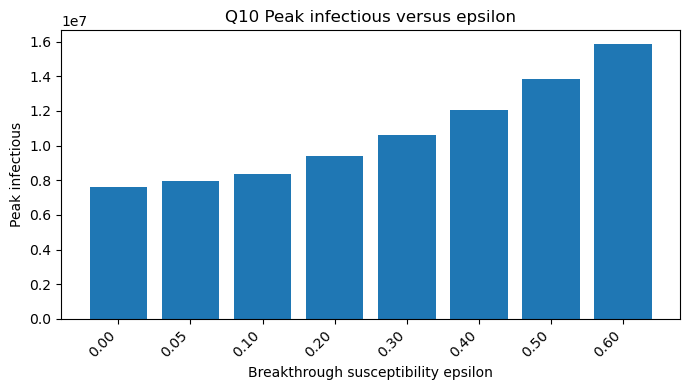

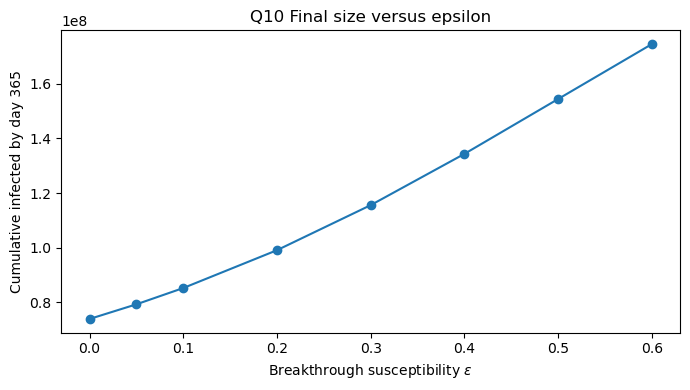

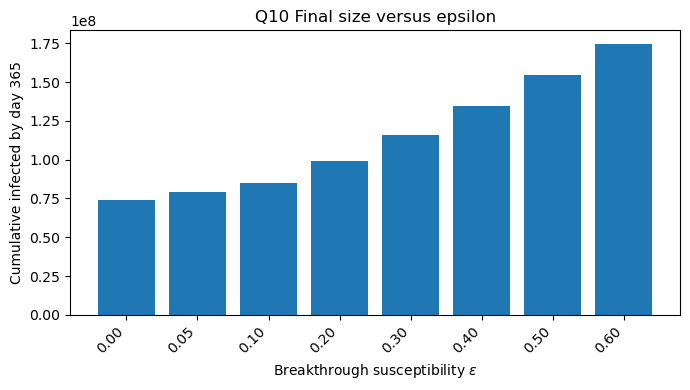

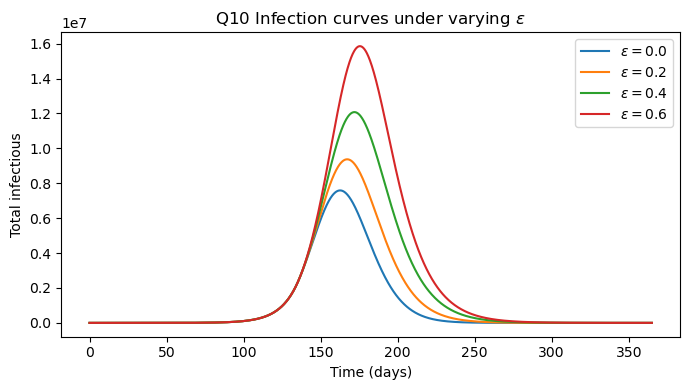

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from textwrap import dedent

# Simulator that accepts epsp
def simulate_two_group_full_beta_fixed(
    tauP=120.0, tauV=14.0, tauE=2.0,
    T=365.0, dt=0.25,
    N0=340110988.0, q_accept=0.70,
    I0_total=13.0,
    R0_target=1.7, cn=0.40,
    gamma=1.0/5.0, nu=0.02, epsp=0.40,
    cn_ref=0.40
):
    beta0 = (R0_target * gamma) / (1.0 - cn_ref)
    times = np.arange(0.0, T + dt, dt)
    n = len(times)

    Na0 = q_accept * N0
    Nh0 = (1.0 - q_accept) * N0
    I0a = I0_total * q_accept
    I0h = I0_total * (1.0 - q_accept)
    Sa0 = Na0 - I0a
    Sh0 = Nh0 - I0h

    # Sa, Wa, Pa, Ea, Ia, Ra, Sh, Eh, Ih, Rh
    Y = np.zeros((n, 10), dtype=float)
    Y[0, :] = np.array([Sa0, 0.0, 0.0, 0.0, I0a, 0.0, Sh0, 0.0, I0h, 0.0])

    def delay_index(t_now, delay):
        idx = int((t_now - delay) / dt)
        return 0 if idx < 0 else idx

    def lam_from_state(state):
        Sa, Wa, Pa, Ea, Ia, Ra, Sh, Eh, Ih, Rh = state
        Itot = Ia + Ih
        Ntot = Sa + Wa + Pa + Ea + Ia + Ra + Sh + Eh + Ih + Rh
        return beta0 * (1.0 - cn) * (Itot / Ntot)

    for k in range(1, n):
        t = times[k]
        Sa, Wa, Pa, Ea, Ia, Ra, Sh, Eh, Ih, Rh = Y[k-1, :]

        idxE = delay_index(t, tauE)
        idxV = delay_index(t, tauV)

        lam = lam_from_state(Y[k-1, :])
        lam_E = lam_from_state(Y[idxE, :])

        H_P = 1.0 if t >= tauP else 0.0
        H_PV = 1.0 if t >= (tauP + tauV) else 0.0

        Sa_V = Y[idxV, 0]
        v_a = nu * H_P * Sa
        g_a = nu * H_PV * Sa_V

        inc_a_now = lam * (Sa + Wa + epsp * Pa)
        inc_h_now = lam * Sh

        Sa_E, Wa_E, Pa_E, Ea_E, Ia_E, Ra_E, Sh_E, Eh_E, Ih_E, Rh_E = Y[idxE, :]
        inc_a_del = lam_E * (Sa_E + Wa_E + epsp * Pa_E)
        inc_h_del = lam_E * Sh_E

        dSa = -lam * Sa - v_a
        dWa = v_a - lam * Wa - g_a
        dPa = g_a - lam * epsp * Pa

        dEa = inc_a_now - inc_a_del
        dIa = inc_a_del - gamma * Ia
        dRa = gamma * Ia

        dSh = -lam * Sh
        dEh = inc_h_now - inc_h_del
        dIh = inc_h_del - gamma * Ih
        dRh = gamma * Ih

        Y[k, 0] = Sa + dt * dSa
        Y[k, 1] = Wa + dt * dWa
        Y[k, 2] = Pa + dt * dPa
        Y[k, 3] = Ea + dt * dEa
        Y[k, 4] = Ia + dt * dIa
        Y[k, 5] = Ra + dt * dRa
        Y[k, 6] = Sh + dt * dSh
        Y[k, 7] = Eh + dt * dEh
        Y[k, 8] = Ih + dt * dIh
        Y[k, 9] = Rh + dt * dRh

        Y[k, :] = np.maximum(Y[k, :], 0.0)

    Itot = Y[:, 4] + Y[:, 8]
    peak_I_total = float(np.max(Itot))
    t_peak_days = float(times[int(np.argmax(Itot))])
    final_R_total = float(Y[-1, 5] + Y[-1, 9])
    stats = dict(peak_I_total=peak_I_total, t_peak_days=t_peak_days, final_R_total=final_R_total)
    return times, Y, stats

# Q10: vary epsp
BASE = dict(tauP=120.0, tauV=14.0, tauE=2.0, q_accept=0.70, cn=0.40, cn_ref=0.40, nu=0.02, R0_target=1.7, gamma=1.0/5.0)
out_dir = "~/Desktop/MetaMath/Compl"
os.makedirs(out_dir, exist_ok=True)

eps_vals = np.array([0.0, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60])
rows = []
curves = []

for eps in eps_vals:
    t, Y, st = simulate_two_group_full_beta_fixed(epsp=float(eps), **BASE)
    Itot = Y[:, 4] + Y[:, 8]
    curves.append((t, Itot, eps))
    rows.append({"epsilon": float(eps), "peak_I_total": st["peak_I_total"], "t_peak_days": st["t_peak_days"], "final_R_total": st["final_R_total"]})

df = pd.DataFrame(rows)
csv_path = os.path.join(out_dir, "q10_summary_table.csv")
df.to_csv(csv_path, index=False)

# Peak infectious vs epsilon line
plt.figure(figsize=(7,4))
plt.plot(df["epsilon"], df["peak_I_total"], marker="o")
plt.xlabel("Breakthrough susceptibility epsilon")
plt.ylabel("Peak infectious")
plt.tight_layout()
fig_peak_line = os.path.join(out_dir, "q10_peak_vs_epsilon_line.png")
plt.savefig(fig_peak_line, dpi=200)
plt.close()

# Peak infectious vs epsilon bar
plt.figure(figsize=(7,4))
plt.bar([f"{v:.2f}" for v in df["epsilon"]], df["peak_I_total"])
plt.xlabel("Breakthrough susceptibility epsilon")
plt.ylabel("Peak infectious")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
fig_peak_bar = os.path.join(out_dir, "q10_peak_vs_epsilon_bar.png")
#plt.savefig(fig_peak_bar, dpi=200)
#plt.close()

# Final size vs epsilon line
plt.figure(figsize=(7,4))
plt.plot(df["epsilon"], df["final_R_total"], marker="o")
plt.xlabel("Breakthrough susceptibility $\\epsilon$")
plt.ylabel("Cumulative infected by day 365")
plt.tight_layout()
fig_final_line = os.path.join(out_dir, "q10_final_vs_epsilon_line.png")
#plt.savefig(fig_final_line, dpi=200)
#plt.close()

# Final size vs epsilon bar
plt.figure(figsize=(7,4))
plt.bar([f"{v:.2f}" for v in df["epsilon"]], df["final_R_total"])
plt.xlabel("Breakthrough susceptibility $\\epsilon$")
plt.ylabel("Cumulative infected by day 365")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
fig_final_bar = os.path.join(out_dir, "q10_final_vs_epsilon_bar.png")
#plt.savefig(fig_final_bar, dpi=200)
#plt.close()

eps_sel = [0.0, 0.2, 0.4, 0.6]

plt.figure(figsize=(7, 4))
for eps in eps_sel:
    t, Y, _ = simulate_two_group_full_beta_fixed(epsp=float(eps), **BASE)
    Itot = Y[:, 4] + Y[:, 8]
    plt.plot(t, Itot, label=rf"$\epsilon = {eps:.1f}$")

plt.xlabel("Time (days)")
plt.ylabel("Total infectious")
plt.legend()
plt.tight_layout()




### 11. Does leaky protection shift burden between groups



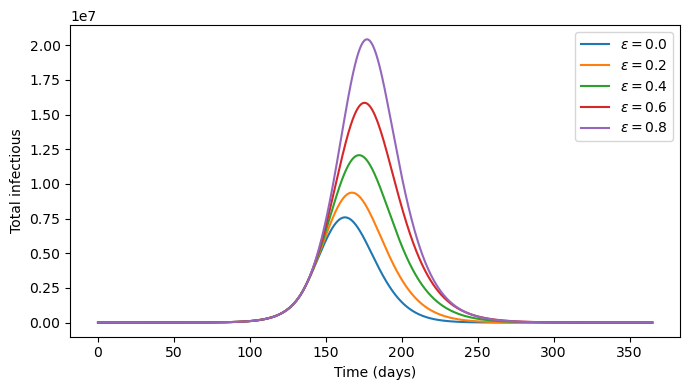

In [47]:
eps_sel = [0.0, 0.2, 0.4, 0.6,0.8]

plt.figure(figsize=(7, 4))
for eps in eps_sel:
    t, Y, _ = simulate_two_group_full_beta_fixed(epsp=float(eps), **BASE)
    Itot = Y[:, 4] + Y[:, 8]
    plt.plot(t, Itot, label=rf"$\epsilon = {eps:.1f}$")

plt.xlabel("Time (days)")
plt.ylabel("Total infectious")
#plt.title(r"Q10 Infection curves under varying $\epsilon$")
plt.legend()
plt.savefig("fig7b.png", dpi=300, bbox_inches="tight")
plt.tight_layout() 
plt.show()


### How delays affect epidemic transients



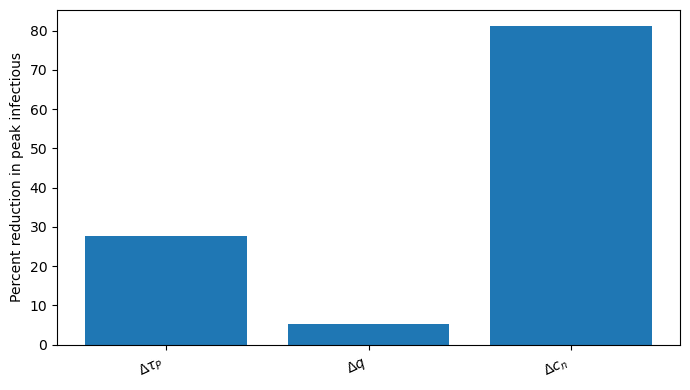

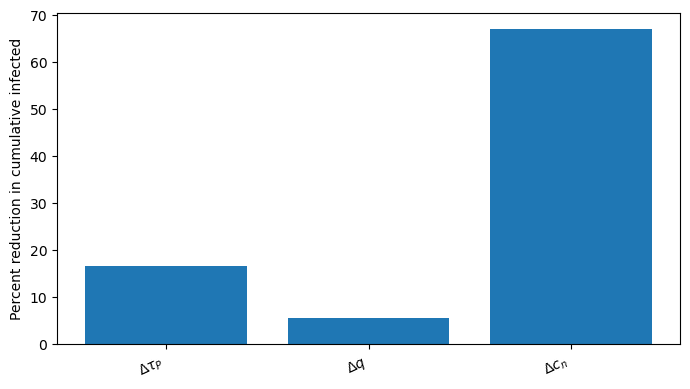

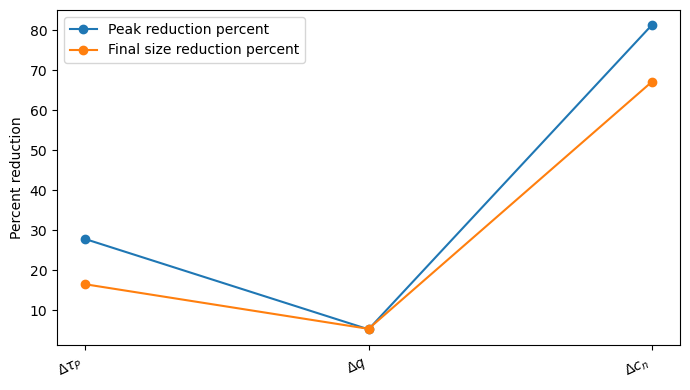

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from textwrap import dedent

def simulate_two_group_full_beta_fixed(
    tauP=120.0, tauV=14.0, tauE=2.0,
    T=365.0, dt=0.25,
    N0=340110988.0, q_accept=0.70,
    I0_total=13.0,
    R0_target=1.7, cn=0.40,
    gamma=1.0/5.0, nu=0.02, epsp=0.40,
    cn_ref=0.40
):
    beta0 = (R0_target * gamma) / (1.0 - cn_ref)
    times = np.arange(0.0, T + dt, dt)
    n = len(times)

    Na0 = q_accept * N0
    Nh0 = (1.0 - q_accept) * N0
    I0a = I0_total * q_accept
    I0h = I0_total * (1.0 - q_accept)
    Sa0 = Na0 - I0a
    Sh0 = Nh0 - I0h

    # Sa, Wa, Pa, Ea, Ia, Ra, Sh, Eh, Ih, Rh
    Y = np.zeros((n, 10), dtype=float)
    Y[0, :] = np.array([Sa0, 0.0, 0.0, 0.0, I0a, 0.0, Sh0, 0.0, I0h, 0.0])

    def delay_index(t_now, delay):
        idx = int((t_now - delay) / dt)
        return 0 if idx < 0 else idx

    def lam_from_state(state):
        Sa, Wa, Pa, Ea, Ia, Ra, Sh, Eh, Ih, Rh = state
        Itot = Ia + Ih
        Ntot = Sa + Wa + Pa + Ea + Ia + Ra + Sh + Eh + Ih + Rh
        return beta0 * (1.0 - cn) * (Itot / Ntot)

    for k in range(1, n):
        t = times[k]
        Sa, Wa, Pa, Ea, Ia, Ra, Sh, Eh, Ih, Rh = Y[k-1, :]

        idxE = delay_index(t, tauE)
        idxV = delay_index(t, tauV)

        lam = lam_from_state(Y[k-1, :])
        lam_E = lam_from_state(Y[idxE, :])

        H_P = 1.0 if t >= tauP else 0.0
        H_PV = 1.0 if t >= (tauP + tauV) else 0.0

        Sa_V = Y[idxV, 0]
        v_a = nu * H_P * Sa
        g_a = nu * H_PV * Sa_V

        inc_a_now = lam * (Sa + Wa + epsp * Pa)
        inc_h_now = lam * Sh

        Sa_E, Wa_E, Pa_E, Ea_E, Ia_E, Ra_E, Sh_E, Eh_E, Ih_E, Rh_E = Y[idxE, :]
        inc_a_del = lam_E * (Sa_E + Wa_E + epsp * Pa_E)
        inc_h_del = lam_E * Sh_E

        dSa = -lam * Sa - v_a
        dWa = v_a - lam * Wa - g_a
        dPa = g_a - lam * epsp * Pa

        dEa = inc_a_now - inc_a_del
        dIa = inc_a_del - gamma * Ia
        dRa = gamma * Ia

        dSh = -lam * Sh
        dEh = inc_h_now - inc_h_del
        dIh = inc_h_del - gamma * Ih
        dRh = gamma * Ih

        Y[k, 0] = Sa + dt * dSa
        Y[k, 1] = Wa + dt * dWa
        Y[k, 2] = Pa + dt * dPa
        Y[k, 3] = Ea + dt * dEa
        Y[k, 4] = Ia + dt * dIa
        Y[k, 5] = Ra + dt * dRa
        Y[k, 6] = Sh + dt * dSh
        Y[k, 7] = Eh + dt * dEh
        Y[k, 8] = Ih + dt * dIh
        Y[k, 9] = Rh + dt * dRh

        Y[k, :] = np.maximum(Y[k, :], 0.0)

    Itot = Y[:, 4] + Y[:, 8]
    peak_I_total = float(np.max(Itot))
    final_R_total = float(Y[-1, 5] + Y[-1, 9])
    return peak_I_total, final_R_total

# Q14: compare marginal benefits of three levers
BASE = dict(tauP=120.0, tauV=14.0, tauE=2.0, q_accept=0.70, cn=0.40, epsp=0.40, cn_ref=0.40, nu=0.02, R0_target=1.7, gamma=1.0/5.0)
out_dir = "~/Desktop/MetaMath/Compl"
os.makedirs(out_dir, exist_ok=True)

peak0, final0 = simulate_two_group_full_beta_fixed(**BASE)

# define "unit change"
d_tauP = 10.0      # days reduced
d_q = 0.05         # acceptance increased
d_cn = 0.05        # NPI compliance increased

# compute outcomes after one unit improvement for each lever
peak_tauP, final_tauP = simulate_two_group_full_beta_fixed(**{**BASE, "tauP": BASE["tauP"] - d_tauP})
peak_q, final_q = simulate_two_group_full_beta_fixed(**{**BASE, "q_accept": min(0.99, BASE["q_accept"] + d_q)})
peak_cn, final_cn = simulate_two_group_full_beta_fixed(**{**BASE, "cn": min(0.95, BASE["cn"] + d_cn)})

def benefits(peak_new, final_new):
    return {
        "peak_reduction_abs": peak0 - peak_new,
        "peak_reduction_pct": (peak0 - peak_new) / peak0 * 100.0,
        "final_reduction_abs": final0 - final_new,
        "final_reduction_pct": (final0 - final_new) / final0 * 100.0
    }

b_tauP = benefits(peak_tauP, final_tauP)
b_q = benefits(peak_q, final_q)
b_cn = benefits(peak_cn, final_cn)

df = pd.DataFrame([
    {"lever":"$\\Delta \\tau_P$", **b_tauP, "peak_new": peak_tauP, "final_new": final_tauP},
    {"lever":"$\\Delta q$", **b_q, "peak_new": peak_q, "final_new": final_q},
    {"lever":"$\\Delta c_n$", **b_cn, "peak_new": peak_cn, "final_new": final_cn},
])

#df = pd.DataFrame([
#    {"lever":"$\\Delta tau_P by 10 days", **b_tauP, "peak_new": peak_tauP, "final_new": final_tauP},
#    {"lever":"Increase q by 0.05", **b_q, "peak_new": peak_q, "final_new": final_q},
#    {"lever":"Increase cn by 0.05", **b_cn, "peak_new": peak_cn, "final_new": final_cn},
#])
csv_path = os.path.join(out_dir, "q14_marginal_benefits.csv")
df.to_csv(csv_path, index=False)

# Bar charts for percent reductions
plt.figure(figsize=(7,4))
plt.bar(df["lever"], df["peak_reduction_pct"])
plt.ylabel("Percent reduction in peak infectious")
#plt.title("Q14 Marginal benefit per unit change: peak reduction")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
fig_peak_bar = os.path.join(out_dir, "fig8a.png")
plt.savefig(fig_peak_bar, dpi=200)
#plt.close()

plt.figure(figsize=(7,4))
plt.bar(df["lever"], df["final_reduction_pct"])
plt.ylabel("Percent reduction in cumulative infected")
#plt.title("Q14 Marginal benefit per unit change: final size reduction")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
fig_final_bar = os.path.join(out_dir, "fig8b.png")
plt.savefig(fig_final_bar, dpi=200)
#plt.close()

# Combined comparison plot using simple markers (two metrics)
plt.figure(figsize=(7,4))
x = np.arange(len(df))
plt.plot(x, df["peak_reduction_pct"], marker="o", label="Peak reduction percent")
plt.plot(x, df["final_reduction_pct"], marker="o", label="Final size reduction percent")
plt.xticks(x, df["lever"], rotation=25, ha="right")
plt.ylabel("Percent reduction")
#plt.title("Q14 Marginal benefit comparison across levers")
plt.legend()
plt.tight_layout()
fig_combo = os.path.join(out_dir, "q14_benefit_combo.png")
#plt.savefig(fig_combo, dpi=200)
#plt.close()




In [ ]:
# Bar charts for percent reductions
plt.figure(figsize=(7,4))
plt.bar(df["lever"], df["peak_reduction_pct"])
plt.ylabel("Percent reduction in peak infectious")
#plt.title("Q14 Marginal benefit per unit change: peak reduction")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
fig_peak_bar = os.path.join(out_dir, "fig8a.png")
plt.savefig(fig_peak_bar, dpi=200)
#plt.close()

plt.figure(figsize=(7,4))
plt.bar(df["lever"], df["final_reduction_pct"])
plt.ylabel("Percent reduction in cumulative infected")
plt.title("Q14 Marginal benefit per unit change: final size reduction")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
fig_final_bar = os.path.join(out_dir, "q14_final_benefit_bar.png")
#plt.savefig(fig_final_bar, dpi=200)
#plt.close()


### Can mixed moderate interventions match extreme single interventions


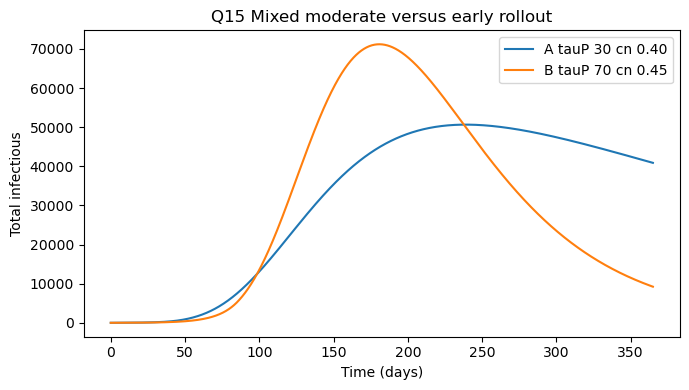

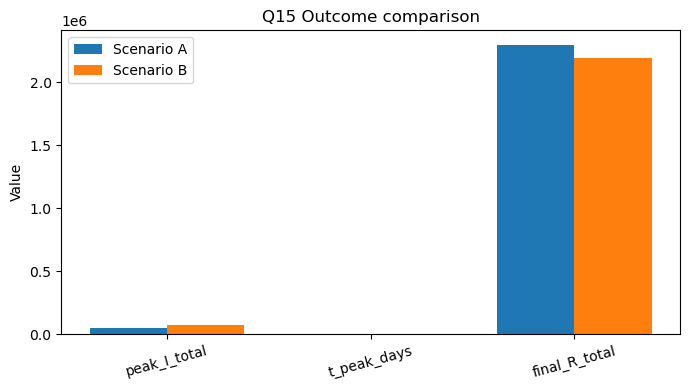

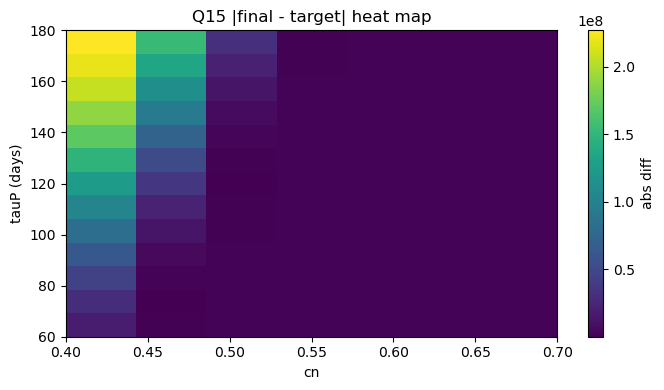

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from textwrap import dedent

def simulate_two_group_full_beta_fixed(
    tauP=120.0, tauV=14.0, tauE=2.0,
    T=365.0, dt=0.25,
    N0=340110988.0, q_accept=0.70,
    I0_total=10.0,
    R0_target=1.7, cn=0.40,
    gamma=1.0/5.0, nu=0.02, epsp=0.40,
    cn_ref=0.40
):
    beta0 = (R0_target * gamma) / (1.0 - cn_ref)
    times = np.arange(0.0, T + dt, dt)
    n = len(times)

    Na0 = q_accept * N0
    Nh0 = (1.0 - q_accept) * N0
    I0a = I0_total * q_accept
    I0h = I0_total * (1.0 - q_accept)
    Sa0 = Na0 - I0a
    Sh0 = Nh0 - I0h

    Y = np.zeros((n, 10), dtype=float)
    Y[0, :] = np.array([Sa0, 0.0, 0.0, 0.0, I0a, 0.0, Sh0, 0.0, I0h, 0.0])

    def delay_index(t_now, delay):
        idx = int((t_now - delay) / dt)
        return 0 if idx < 0 else idx

    def lam_from_state(state):
        Sa, Wa, Pa, Ea, Ia, Ra, Sh, Eh, Ih, Rh = state
        Itot = Ia + Ih
        Ntot = Sa + Wa + Pa + Ea + Ia + Ra + Sh + Eh + Ih + Rh
        return beta0 * (1.0 - cn) * (Itot / Ntot)

    for k in range(1, n):
        t = times[k]
        Sa, Wa, Pa, Ea, Ia, Ra, Sh, Eh, Ih, Rh = Y[k-1, :]

        idxE = delay_index(t, tauE)
        idxV = delay_index(t, tauV)

        lam = lam_from_state(Y[k-1, :])
        lam_E = lam_from_state(Y[idxE, :])

        H_P = 1.0 if t >= tauP else 0.0
        H_PV = 1.0 if t >= (tauP + tauV) else 0.0

        Sa_V = Y[idxV, 0]
        v_a = nu * H_P * Sa
        g_a = nu * H_PV * Sa_V

        inc_a_now = lam * (Sa + Wa + epsp * Pa)
        inc_h_now = lam * Sh

        Sa_E, Wa_E, Pa_E, Ea_E, Ia_E, Ra_E, Sh_E, Eh_E, Ih_E, Rh_E = Y[idxE, :]
        inc_a_del = lam_E * (Sa_E + Wa_E + epsp * Pa_E)
        inc_h_del = lam_E * Sh_E

        dSa = -lam * Sa - v_a
        dWa = v_a - lam * Wa - g_a
        dPa = g_a - lam * epsp * Pa

        dEa = inc_a_now - inc_a_del
        dIa = inc_a_del - gamma * Ia
        dRa = gamma * Ia

        dSh = -lam * Sh
        dEh = inc_h_now - inc_h_del
        dIh = inc_h_del - gamma * Ih
        dRh = gamma * Ih

        Y[k, 0] = Sa + dt * dSa
        Y[k, 1] = Wa + dt * dWa
        Y[k, 2] = Pa + dt * dPa
        Y[k, 3] = Ea + dt * dEa
        Y[k, 4] = Ia + dt * dIa
        Y[k, 5] = Ra + dt * dRa
        Y[k, 6] = Sh + dt * dSh
        Y[k, 7] = Eh + dt * dEh
        Y[k, 8] = Ih + dt * dIh
        Y[k, 9] = Rh + dt * dRh

        Y[k, :] = np.maximum(Y[k, :], 0.0)

    Itot = Y[:, 4] + Y[:, 8]
    peak_I_total = float(np.max(Itot))
    t_peak_days = float(times[int(np.argmax(Itot))])
    final_R_total = float(Y[-1, 5] + Y[-1, 9])
    return times, Y, dict(peak_I_total=peak_I_total, t_peak_days=t_peak_days, final_R_total=final_R_total)

BASE = dict(tauV=14.0, tauE=2.0, q_accept=0.70, epsp=0.40, cn_ref=0.40, nu=0.02, R0_target=1.7, gamma=1.0/5.0)
out_dir = "~/Desktop/MetaMath/Compl"
os.makedirs(out_dir, exist_ok=True)

# Define extreme single intervention: "perfect rollout alone" meaning early tauP with baseline cn and q
scenario_A = {"name":"A perfect rollout", "tauP":30.0, "cn":0.40}

# Find a mixed moderate scenario that matches final size within tolerance
target_final = simulate_two_group_full_beta_fixed(tauP=scenario_A["tauP"], cn=scenario_A["cn"], **BASE)[2]["final_R_total"]

# Grid for mixed scenario: moderate tauP, moderate cn (and baseline q)
tauP_grid = np.arange(60.0, 181.0, 10.0)
cn_grid = np.arange(0.40, 0.71, 0.05)

best = None
records = []
for tauP in tauP_grid:
    for cn in cn_grid:
        t, Y, st = simulate_two_group_full_beta_fixed(tauP=float(tauP), cn=float(cn), **BASE)
        diff = abs(st["final_R_total"] - target_final)
        records.append({"tauP": float(tauP), "cn": float(cn), "final_R": st["final_R_total"], "peak_I": st["peak_I_total"], "t_peak": st["t_peak_days"], "abs_diff_to_target_final": diff})
        if best is None or diff < best["abs_diff_to_target_final"]:
            best = records[-1]

df_grid = pd.DataFrame(records)
csv_grid = os.path.join(out_dir, "q15_grid.csv")
df_grid.to_csv(csv_grid, index=False)

scenario_B = {"name":"B mixed moderate", "tauP": best["tauP"], "cn": best["cn"]}

# Simulate both for curve plots
tA, YA, stA = simulate_two_group_full_beta_fixed(tauP=scenario_A["tauP"], cn=scenario_A["cn"], **BASE)
tB, YB, stB = simulate_two_group_full_beta_fixed(tauP=scenario_B["tauP"], cn=scenario_B["cn"], **BASE)

ItotA = YA[:,4] + YA[:,8]
ItotB = YB[:,4] + YB[:,8]

# Overlay time series comparison
plt.figure(figsize=(7,4))
plt.plot(tA, ItotA, label=f"A tauP {int(scenario_A['tauP'])} cn {scenario_A['cn']:.2f}")
plt.plot(tB, ItotB, label=f"B tauP {int(scenario_B['tauP'])} cn {scenario_B['cn']:.2f}")
plt.xlabel("Time (days)")
plt.ylabel("Total infectious")

plt.legend()
plt.tight_layout()
fig_overlay = os.path.join(out_dir, "q15_compare_Itot.png")
plt.savefig(fig_overlay, dpi=200)
#plt.close()

# Bar chart comparison of key outcomes
labels = ["peak_I_total", "t_peak_days", "final_R_total"]
A_vals = [stA["peak_I_total"], stA["t_peak_days"], stA["final_R_total"]]
B_vals = [stB["peak_I_total"], stB["t_peak_days"], stB["final_R_total"]]

x = np.arange(len(labels))
width = 0.38
plt.figure(figsize=(7,4))
plt.bar(x - width/2, A_vals, width, label="Scenario A")
plt.bar(x + width/2, B_vals, width, label="Scenario B")
plt.xticks(x, labels, rotation=15)
plt.ylabel("Value")

plt.legend()
plt.tight_layout()
fig_bar = os.path.join(out_dir, "q15_outcome_bar.png")
plt.savefig(fig_bar, dpi=200)
#plt.close()

# Heat map of abs diff in final size relative to target
pivot = df_grid.pivot(index="tauP", columns="cn", values="abs_diff_to_target_final").sort_index()
plt.figure(figsize=(7,4))
plt.imshow(pivot.values, aspect="auto", origin="lower",
           extent=[pivot.columns.min(), pivot.columns.max(), pivot.index.min(), pivot.index.max()])
plt.xlabel("cn")
plt.ylabel("tauP (days)")

plt.colorbar(label="abs diff")
plt.tight_layout()
fig_heat = os.path.join(out_dir, "q15_diff_heatmap.png")
plt.savefig(fig_heat, dpi=200)
#plt.close()

# Summary table
df_summary = pd.DataFrame([
    {"scenario":"A", **scenario_A, **stA},
    {"scenario":"B", **scenario_B, **stB},
]).drop(columns=["name"])

csv_summary = os.path.join(out_dir, "q15_summary.csv")
df_summary.to_csv(csv_summary, index=False)


